In [278]:
pip install elasticsearch

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


#                                               Assignment1 - PART 1

Data sources for experiments: preprocess the data including word stemming and stopping, handle any special symbols like punctuation appropriately. Generate word frequency plots with and without text preprocessing. Index the data into Elasticsearch, name it ESIndex-v1.0.

1. News data at webz.io available on github.
2. Wiki data from huggingface use the split 20231101.en. --> Only indexing wiki data


### 1. Laod Dataset

In [279]:
import warnings

warnings.filterwarnings("ignore")
import os
from datasets import load_from_disk

# download and save the dataset locally if not already done
# ds = load_dataset("wikimedia/wikipedia", "20231101.en")
# ds.save_to_disk("wikidata")

# get dataset path
current_directory = os.getcwd()
print(f"Current Working Dicrectory : {current_directory}")

# upper_dir = current_directory.split("models")[0]
dataset_path = f"{current_directory}/wikidata/train"
print(f"Dataset Path : {dataset_path}")

# load the dataset
dataset = load_from_disk(dataset_path)

Current Working Dicrectory : /Users/darmojudeekshitha/Documents/PGSSP/IRE/Assignment1/indexing_a1
Dataset Path : /Users/darmojudeekshitha/Documents/PGSSP/IRE/Assignment1/indexing_a1/wikidata/train


Loading dataset from disk:   0%|          | 0/41 [00:00<?, ?it/s]

### Preprocess the Dataset

In [280]:
import sys
import os

sys.path.append(os.path.abspath(".."))


from core.preprocessor import Preprocessor

preprocessor = Preprocessor()

print(preprocessor.preprocess(dataset[0]["text"]))

raw_word_freq = preprocessor.get_word_freq(dataset, use_preprocessing=False)
cleaned_word_freq = preprocessor.get_word_freq(dataset, use_preprocessing=True)

print(f"Raw Word Frequency : {len(raw_word_freq)}")
print(f"Cleaned Word Frequency : {len(cleaned_word_freq)}")

['anarch', 'polit', 'philosophi', 'movement', 'skeptic', 'justif', 'author', 'seek', 'abolish', 'institut', 'claim', 'maintain', 'unnecessari', 'coercion', 'hierarchi', 'typic', 'includ', 'nation', 'state', 'capit', 'anarch', 'advoc', 'replac', 'state', 'stateless', 'societi', 'voluntari', 'free', 'associ', 'histor', 'left', 'wing', 'movement', 'read', 'anarch', 'place', 'farthest', 'left', 'polit', 'spectrum', 'usual', 'describ', 'libertarian', 'wing', 'socialist', 'movement', 'libertarian', 'social', 'human', 'live', 'societi', 'without', 'formal', 'hierarchi', 'long', 'establish', 'state', 'realm', 'empir', 'rise', 'organis', 'hierarch', 'bodi', 'sceptic', 'toward', 'author', 'also', 'rose', 'although', 'trace', 'anarchist', 'idea', 'found', 'throughout', 'histori', 'modern', 'anarch', 'emerg', 'enlighten', 'latter', 'half', '19th', 'first', 'decad', '20th', 'centuri', 'anarchist', 'movement', 'flourish', 'part', 'world', 'signific', 'role', 'worker', 'struggl', 'emancip', 'various'

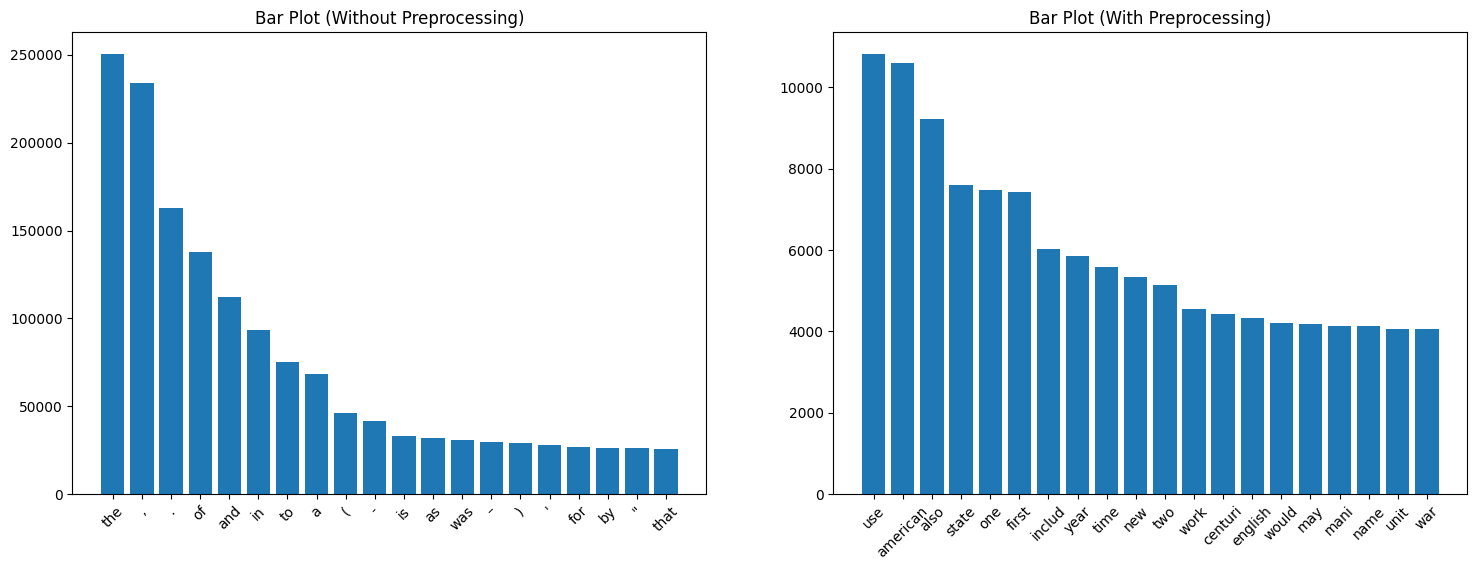

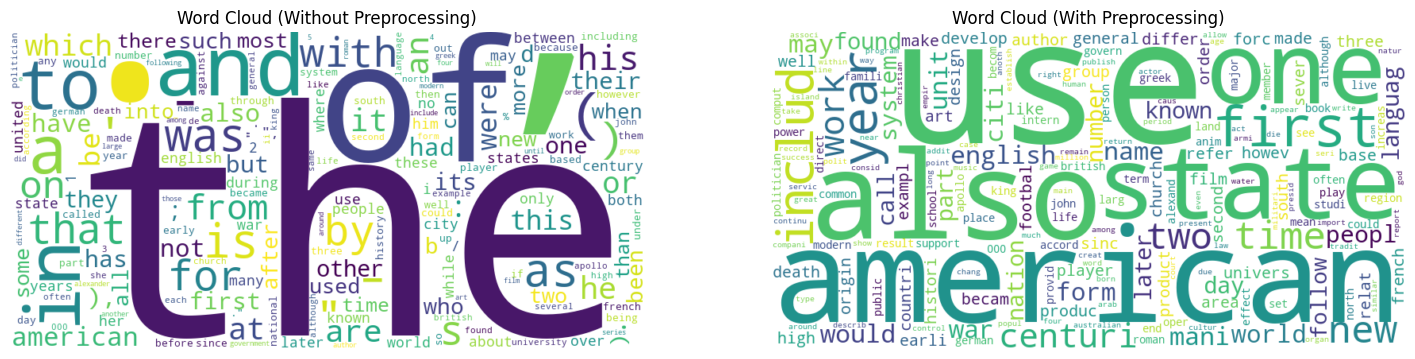

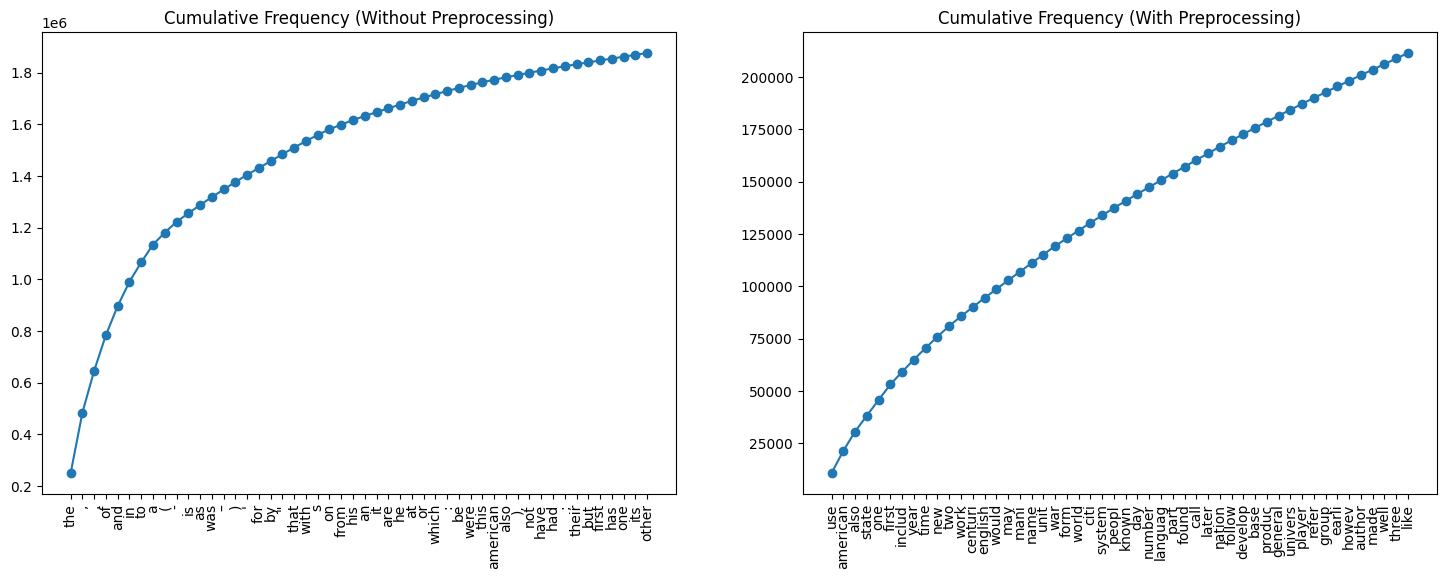

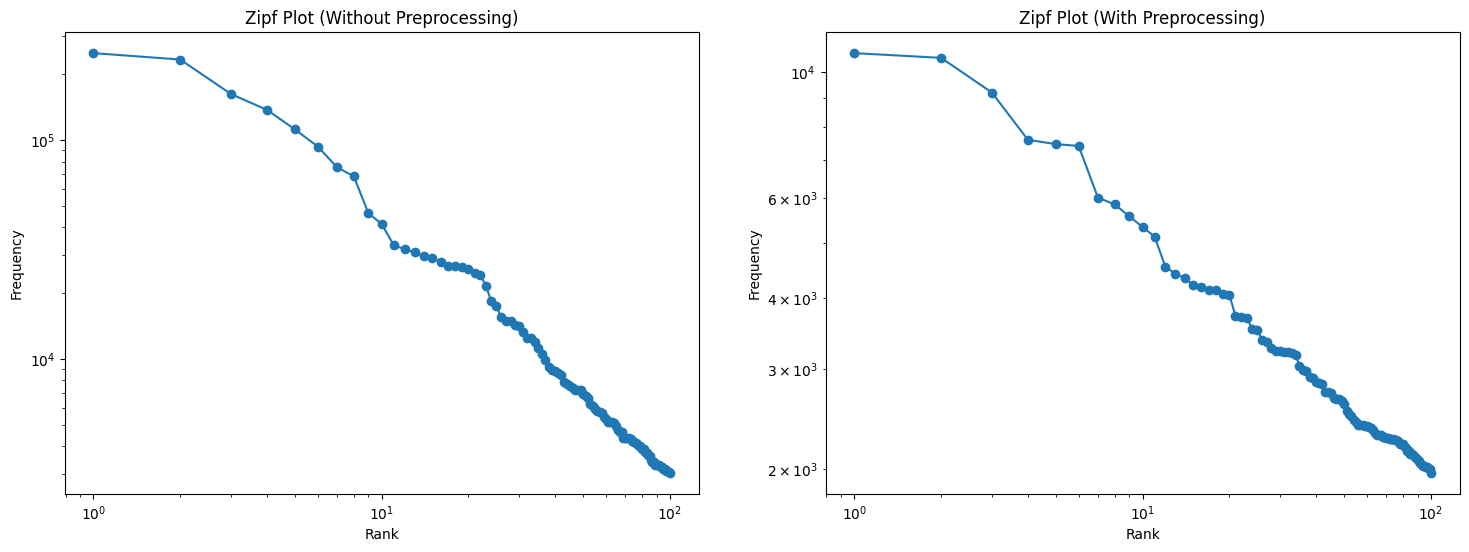

In [281]:
preprocessor.plot_comparison_all(raw_word_freq, cleaned_word_freq)

### Elastic search installation

1. brew tap elastic/tap
2. brew install elastic/tap/elasticsearch-full

### Start Elastic search

1. brew services start elastic/tap/elasticsearch-full
2. brew services list
                
(OR)

- Run */opt/homebrew/opt/elasticsearch-full/bin/elasticsearch*

In [282]:
import subprocess
from pathlib import Path

Path("logs").mkdir(parents=True, exist_ok=True)


def run_index_helper(stdoutlog, stderrlog, configfile):
    with open(stdoutlog, "a") as out, open(stderrlog, "a") as err:
        out.write("\n\n--- New Run ---\n")
        err.write("\n\n--- New Run ---\n")
        result = subprocess.run(
            [
                "python3",
                "index_helper.py",
                "40000",
                "10",
                "5000",
                configfile,
            ],
            stdout=out,
            stderr=err,
            text=True,
        )

    print(f"Output saved to {stdoutlog} and {stderrlog}")


def run_query_helper(stdoutlog, stderrlog, configfile):
    with open(stdoutlog, "a") as out, open(stderrlog, "a") as err:
        out.write("\n\n--- New Run ---\n")
        err.write("\n\n--- New Run ---\n")
        result = subprocess.run(
            [
                "python3",
                "query_helper.py",
                configfile,
            ],
            stdout=out,
            stderr=err,
            text=True,
        )

    print(f"Output saved to {stdoutlog} and {stderrlog}")

In [283]:
run_index_helper(
    "logs/index_es_stdout.log",
    "logs/index_es_stderr.log",
    "configs/config_es.json",
)

Output saved to logs/index_es_stdout.log and logs/index_es_stderr.log


In [284]:
from models.ESIndex import ESIndex

es = ESIndex()
es.es.count(index="wiki_index")

True
{'name': 'DARMOJUs-MacBook-Pro.local', 'cluster_name': 'elasticsearch_darmojudeekshitha', 'cluster_uuid': 'KqSvmFGtRNC2LybFL92vHw', 'version': {'number': '7.17.4', 'build_flavor': 'default', 'build_type': 'tar', 'build_hash': '79878662c54c886ae89206c685d9f1051a9d6411', 'build_date': '2022-05-18T18:04:20.964345128Z', 'build_snapshot': False, 'lucene_version': '8.11.1', 'minimum_wire_compatibility_version': '6.8.0', 'minimum_index_compatibility_version': '6.0.0-beta1'}, 'tagline': 'You Know, for Search'}


ObjectApiResponse({'count': 40000, '_shards': {'total': 1, 'successful': 1, 'skipped': 0, 'failed': 0}})

In [285]:
def pretty_response(response):
    if len(response["hits"]["hits"]) == 0:
        print("Your search returned no results.")
    else:
        for hit in response["hits"]["hits"]:
            id = hit["_id"]
            # publication_date = hit["_source"]["publish_date"]
            score = hit["_score"]
            title = hit["_source"]["title"]
            pretty_output = f"\nID: {id}\nTitle: {title}\nScore: {score}"
            print(pretty_output)

In [286]:
test_queries = [
    # Single terms
    "art",
    "form",
    "america",
    # Basic boolean
    "art AND form",
    "art OR form",
    "art AND NOT form",
    "NOT art",
    # Phrase queries
    '"art form"',
    '"modern art"',
    '"form of art"',
    # Mixed
    '"art form" AND "modern art"',
    '"art form" OR art',
    '"modern art" AND NOT form',
    '"art form" OR "form art"',
    # Grouped
    '("art" AND "form") OR ("america" AND "state")',
    '("art" OR "form") AND ("america" OR "state")',
    '("art" AND NOT "form") OR ("form" AND NOT "art")',
    '(art OR form) AND NOT "america"',
    # Nested
    '(("art" AND "form") OR "america") AND NOT "state"',
    '(("art" OR "form") AND ("america" OR "state"))',
    '("art" AND ("form" OR "america"))',
    '("art" AND ("form" AND ("america" OR "state")))',
    # Edge / tricky
    "art form",
    '"art form" OR art',
    '"form" AND NOT "form"',
    "(art)",
    'NOT ("art" AND "form")',
]
for q in test_queries:
    response = es.query(q)
    # print(response)
    print("=" * 60)
    print(f"Query : {q}")
    pretty_response(response)

Query : art

ID: 98
Title: Art
Score: 4.380942

ID: 31069
Title: Zimmerli Art Museum at Rutgers University
Score: 4.359273

ID: 32469
Title: Arts festival
Score: 4.3581953

ID: 692
Title: ASCII art
Score: 4.3507257

ID: 39192
Title: School of Creative and Performing Arts
Score: 4.3440666

ID: 35617
Title: Saul Ostrow
Score: 4.343973

ID: 33757
Title: ART.Welten
Score: 4.343837

ID: 34377
Title: Eva Rothschild
Score: 4.34311

ID: 7908
Title: Amelia Jones
Score: 4.3232036

ID: 36536
Title: Franko B
Score: 4.3199263
Query : form

ID: 1260
Title: Convex uniform honeycomb
Score: 3.041129

ID: 19146
Title: Quadratic form (statistics)
Score: 3.020224

ID: 14938
Title: Modern Greek grammar
Score: 3.0061107

ID: 8765
Title: Hyeong
Score: 2.9988482

ID: 5605
Title: Vertical and horizontal bundles
Score: 2.998363

ID: 6049
Title: Liesegang rings
Score: 2.9978302

ID: 37490
Title: Fractus cloud
Score: 2.9751654

ID: 26585
Title: Witt's theorem
Score: 2.9704547

ID: 14845
Title: Bartoli indole synt

In [287]:
add_files = [("Updated title for 1000", "Updated text content goes here.")]

es.update_index(index_id=1000, remove_files=[], add_files=add_files)  # or None

In [288]:
for q in test_queries:
    response = es.query(q)
    # print(response)
    print("=" * 60)
    print(f"Query : {q}")
    pretty_response(response)

Query : art

ID: 98
Title: Art
Score: 4.380942

ID: 31069
Title: Zimmerli Art Museum at Rutgers University
Score: 4.359273

ID: 32469
Title: Arts festival
Score: 4.3581953

ID: 692
Title: ASCII art
Score: 4.3507257

ID: 39192
Title: School of Creative and Performing Arts
Score: 4.3440666

ID: 35617
Title: Saul Ostrow
Score: 4.343973

ID: 33757
Title: ART.Welten
Score: 4.343837

ID: 34377
Title: Eva Rothschild
Score: 4.34311

ID: 7908
Title: Amelia Jones
Score: 4.3232036

ID: 36536
Title: Franko B
Score: 4.3199263
Query : form

ID: 1260
Title: Convex uniform honeycomb
Score: 3.041129

ID: 19146
Title: Quadratic form (statistics)
Score: 3.020224

ID: 14938
Title: Modern Greek grammar
Score: 3.0061107

ID: 8765
Title: Hyeong
Score: 2.9988482

ID: 5605
Title: Vertical and horizontal bundles
Score: 2.998363

ID: 6049
Title: Liesegang rings
Score: 2.9978302

ID: 37490
Title: Fractus cloud
Score: 2.9751654

ID: 26585
Title: Witt's theorem
Score: 2.9704547

ID: 14845
Title: Bartoli indole synt

In [289]:
es.delete_index(index_id=1000)

In [290]:
# es.delete_whole_index()

In [291]:
if es.es.indices.exists(index="wiki_index"):
    print("index exists")
else:
    print("No index")

index exists


### Measure query latencies for ES

In [292]:
run_query_helper(
    "./logs/query_es_stdout.log",
    "./logs/query_es_stderr.log",
    "configs/config_es.json",
)

Output saved to ./logs/query_es_stdout.log and ./logs/query_es_stderr.log


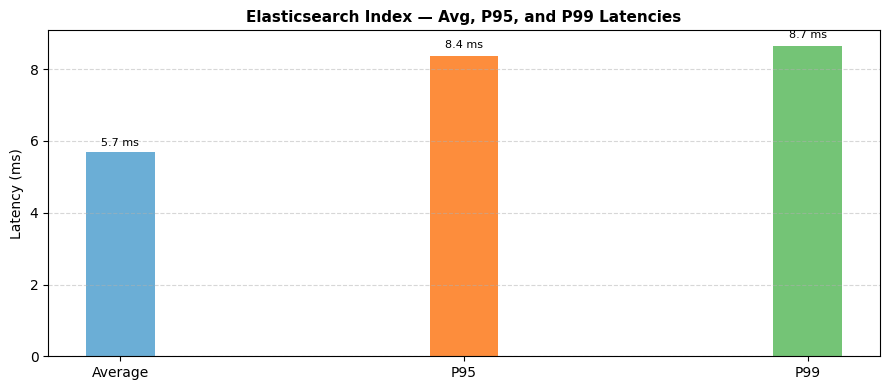

In [293]:
import pandas as pd
import matplotlib.pyplot as plt

# Read the CSV
df = pd.read_csv("query_latency_log.csv")

# Filter only Elasticsearch entries
df_es = df[df["index_type"] == "es"]

# Group and aggregate
group_cols = [
    "info",
    "dstore",
    "qproc",
    "compr",
    "optim",
    "query_type",
    "run_id",
]
grouped = df_es.groupby(group_cols)["latency_ms"]

summary = grouped.agg(
    avg_latency_ms="mean",
    p95_latency_ms=lambda x: x.quantile(0.95),
    p99_latency_ms=lambda x: x.quantile(0.99),
).reset_index()

# Compute overall averages (across runs/configs)
overall = summary[["avg_latency_ms", "p95_latency_ms", "p99_latency_ms"]].mean()

# Plot setup
labels = ["Average", "P95", "P99"]
colors = ["#6baed6", "#fd8d3c", "#74c476"]  # dark skyblue, orange, green

plt.figure(figsize=(9, 4))
# bars = plt.bar(
#     labels, overall, color=colors, width=0.4, edgecolor="black", linewidth=0.8
# )

bars = plt.bar(labels, overall, color=colors, width=0.2)

# Labels and style
plt.ylabel("Latency (ms)", fontsize=10)
plt.title(
    "Elasticsearch Index — Avg, P95, and P99 Latencies", fontsize=11, weight="bold"
)
plt.grid(axis="y", linestyle="--", alpha=0.5)

# Add value labels on top of each bar
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.02 * height,
        f"{height:.1f} ms",
        ha="center",
        va="bottom",
        fontsize=8,
    )

plt.tight_layout()
plt.show()

  query_type       avg      p95      p99
0    BOOLEAN  2.809700  3.69490  3.73898
1       EDGE  2.405440  3.64240  5.92272
2    GROUPED  3.596450  5.23720  5.36184
3      MIXED  1.896100  2.71895  4.69419
4     NESTED  4.039700  5.21740  5.23868
5     PHRASE  1.327600  2.12000  2.94320
6       TERM  2.782214  3.91620  4.07844


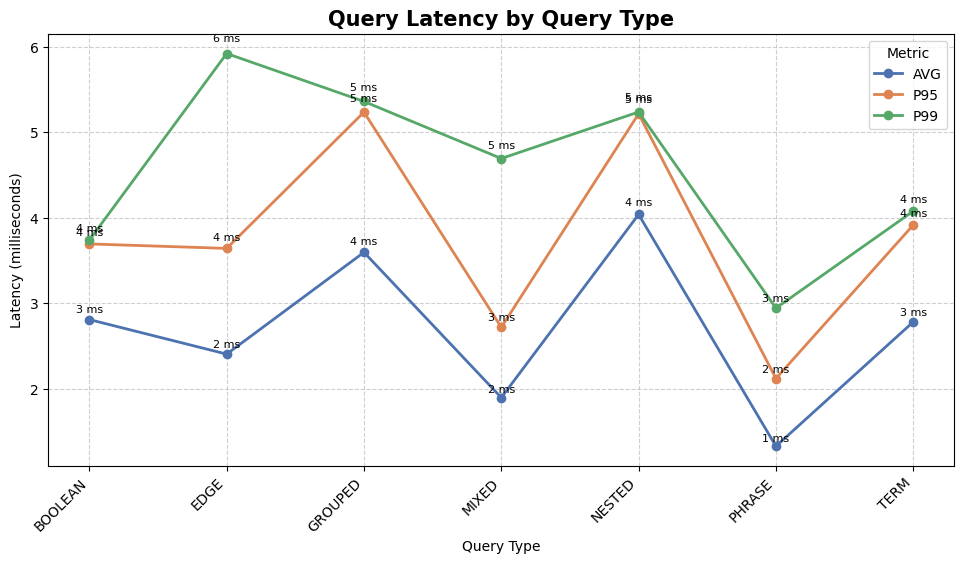

In [332]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load CSV
df = pd.read_csv("query_latency_log.csv", header=None)

# Define columns
df.columns = [
    "timestamp",
    "index_type",
    "info",
    "dstore",
    "compr",
    "qproc",
    "optim",
    "query",
    "query_type",
    "run_id",
    "latency_ms",
    "current_mem_kb",
    "peak_mem_kb",
]

# Filter only ES index type
df = df[df["index_type"].str.lower() == "es"]

# Clean query_type text
df["query_type"] = df["query_type"].astype(str).str.strip().str.upper()

# Convert latency to numeric and drop NaN
df["latency_ms"] = pd.to_numeric(df["latency_ms"], errors="coerce")
df = df.dropna(subset=["latency_ms"])
df = df.sort_values("timestamp")

# Exclude the first TERM query
first_term_query = df[df["query_type"] == "TERM"].head(1)
df_excluding_first = df.drop(first_term_query.index)

# Aggregate latency metrics by query_type
agg = (
    df_excluding_first.groupby("query_type")["latency_ms"]
    .agg(
        avg="mean",
        p95=lambda x: x.quantile(0.95),
        p99=lambda x: x.quantile(0.99),
    )
    .reset_index()
)

print(agg)

# ---- Line Chart in ms ----
metrics = ["avg", "p95", "p99"]
colors = {"avg": "#4C72B0", "p95": "#DD8452", "p99": "#55A868"}

query_types = sorted(agg["query_type"].unique())
x = np.arange(len(query_types))

plt.figure(figsize=(10, 6))
plt.title(
    "Query Latency by Query Type",
    fontsize=15,
    weight="bold",
)

for metric in metrics:
    y_vals = agg.set_index("query_type").loc[query_types, metric]
    plt.plot(
        x,
        y_vals,
        label=metric.upper(),
        color=colors[metric],
        marker="o",
        linewidth=2,
        markersize=6,
    )
    # Add value labels
    for i, val in enumerate(y_vals):
        plt.text(
            x[i],
            val + 0.02 * val,
            f"{val:.0f} ms",
            ha="center",
            va="bottom",
            fontsize=8,
        )

plt.xticks(x, query_types, rotation=45, ha="right")
plt.xlabel("Query Type")
plt.ylabel("Latency (milliseconds)")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(title="Metric", frameon=True)
plt.tight_layout(pad=2.0)
plt.show()

  query_type       avg      p95      p99
0    BOOLEAN  2.809700  3.69490  3.73898
1       EDGE  2.405440  3.64240  5.92272
2    GROUPED  3.596450  5.23720  5.36184
3      MIXED  1.896100  2.71895  4.69419
4     NESTED  4.039700  5.21740  5.23868
5     PHRASE  1.327600  2.12000  2.94320
6       TERM  2.782214  3.91620  4.07844


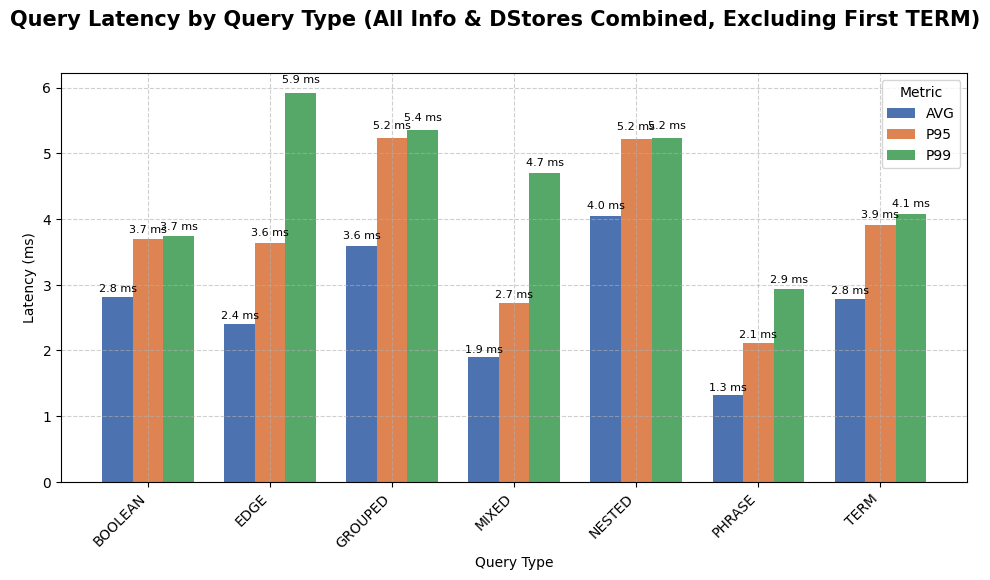

In [333]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load CSV
df = pd.read_csv("query_latency_log.csv", header=None)

# Define columns
df.columns = [
    "timestamp",
    "index_type",
    "info",
    "dstore",
    "compr",
    "qproc",
    "optim",
    "query",
    "query_type",
    "run_id",
    "latency_ms",
    "current_mem_kb",
    "peak_mem_kb",
]

# Filter for ES index type
df = df[df["index_type"].str.lower() == "es"]

# Clean and standardize text fields
df["query_type"] = df["query_type"].astype(str).str.strip().str.upper()

# Convert latency to numeric and clean
df["latency_ms"] = pd.to_numeric(df["latency_ms"], errors="coerce")
df = df.dropna(subset=["latency_ms"])
df = df.sort_values("timestamp")

# Exclude the first TERM query overall (not per info)
first_term_query = df[df["query_type"] == "TERM"].head(1)
df_excluding_first = df.drop(first_term_query.index)

# Aggregate only by query_type
agg = (
    df_excluding_first.groupby("query_type")["latency_ms"]
    .agg(
        avg="mean",
        p95=lambda x: x.quantile(0.95),
        p99=lambda x: x.quantile(0.99),
    )
    .reset_index()
)

print(agg)

# Plot settings
metrics = ["avg", "p95", "p99"]
colors = {"avg": "#4C72B0", "p95": "#DD8452", "p99": "#55A868"}

# Plot latency comparison across query types
fig, ax = plt.subplots(figsize=(10, 6))
fig.suptitle(
    "Query Latency by Query Type (All Info & DStores Combined, Excluding First TERM)",
    fontsize=15,
    weight="bold",
)

query_types = sorted(agg["query_type"].unique())
x = np.arange(len(query_types))
width = 0.25

for i, metric in enumerate(metrics):
    y_vals = agg.set_index("query_type").loc[query_types, metric]  # keep in ms
    ax.bar(
        x + (i - 1) * width,
        y_vals,
        width,
        label=metric.upper(),
        color=colors[metric],
    )

    # Value labels in ms
    for j, val in enumerate(y_vals):
        ax.text(
            x[j] + (i - 1) * width,
            val + 0.02 * val,
            f"{val:.1f} ms",
            ha="center",
            va="bottom",
            fontsize=8,
        )

ax.set_xticks(x)
ax.set_xticklabels(query_types, rotation=45, ha="right")
ax.set_xlabel("Query Type")
ax.set_ylabel("Latency (ms)")
ax.grid(True, linestyle="--", alpha=0.6)
ax.legend(title="Metric", frameon=True)

plt.tight_layout(pad=2.0)
plt.show()

# Assignment1 - PART2

Implement your own simple indexing (SelfIndex-v1.0) over the boilerplate code shared and index the above data into it.
Build SelfIndex-v1.xyziq identified by the versioning number as follows. Structure your code so that you can use this version number to have it build/make the index with right choices and run the query tests on it accordingly. Plot relevant metrics (marked below) for your indexing against that of ES for the corresponding test query set.
    
### a). Plot.C for x=n Iterate over different kinds of information indexed.
1. x=1 Boolean index with document IDs and postition IDs.
2. x=2 Enable ranking with word counts.
3. x=3 Further evaluate gains from adding TF-IDF scores.


In [294]:
run_index_helper(
    "./logs/index_x_stdout.log",
    "./logs/index_x_stderr.log",
    "configs/config_x.json",
)

Output saved to ./logs/index_x_stdout.log and ./logs/index_x_stderr.log


  index_type  info_type  total_time_sec  index_size_mb
0         es    BOOLEAN           68.30         110.63
1       self    BOOLEAN          178.05        1127.40
2       self      TFIDF          215.48        1973.42
3       self  WORDCOUNT          176.41        1127.41


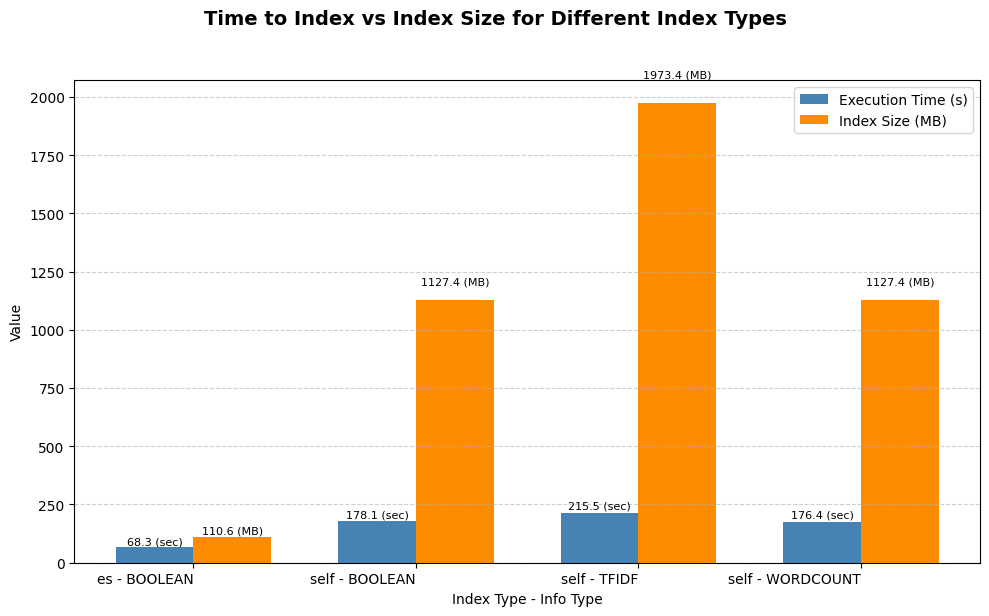

In [300]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import json

with open("index_metrics.json", "r") as f:
    data = json.load(f)

df = pd.DataFrame(data)

df = df[["index_type", "info_type", "total_time_sec", "index_size_mb"]]

print(df)


df["label"] = df["index_type"] + " - " + df["info_type"]

x = np.arange(len(df))  # label locations
width = 0.35  # bar width

fig, ax1 = plt.subplots(figsize=(10, 6))

bar1 = ax1.bar(
    x - width / 2,
    df["total_time_sec"],
    width,
    label="Execution Time (s)",
    color="steelblue",
)

bar2 = ax1.bar(
    x + width / 2,
    df["index_size_mb"],
    width,
    label="Index Size (MB)",
    color="darkorange",
)

ax1.set_xlabel("Index Type - Info Type")
ax1.set_ylabel("Value")
fig.suptitle(
    "Time to Index vs Index Size for Different Index Types",
    fontsize=14,
    weight="bold",
    y=1.02,
)
plt.tight_layout(pad=3.0)
plt.subplots_adjust(bottom=0.18)  # Adds bottom padding for x-axis labels
ax1.set_xticks(x)
ax1.set_xticklabels(df["label"], rotation=0, ha="right")
ax1.legend()
ax1.grid(axis="y", linestyle="--", alpha=0.6)

for bar in bar1:
    height = bar.get_height()
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.05 * height,
        f"{height:.1f} (sec)",
        ha="center",
        va="bottom",
        fontsize=8,
    )

for bar in bar2:
    height = bar.get_height()
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.05 * height,
        f"{height:.1f} (MB)",
        ha="center",
        va="bottom",
        fontsize=8,
    )

plt.tight_layout()
plt.show()

**Explaination** : We can see that the ElasticSearch (es) index is much faster and smaller, whereas self-built indexes take longer and consume more storage

In [302]:
run_query_helper(
    "./logs/query_x_stdout.log",
    "./logs/query_x_stderr.log",
    "configs/config_x.json",
)

Output saved to ./logs/query_x_stdout.log and ./logs/query_x_stderr.log


        info     qproc  avg_peak_mem_mb
0    BOOLEAN  TERMATAT       200.182986
1      TFIDF  TERMATAT       259.471439
2  WORDCOUNT  TERMATAT       183.575746


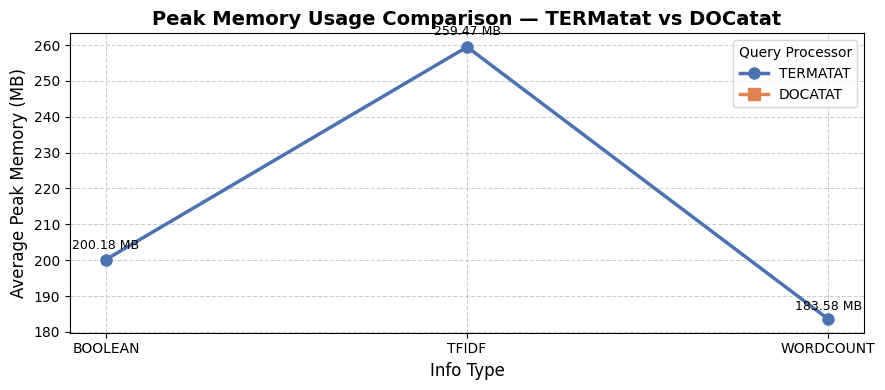

In [306]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("query_latency_log.csv", header=None)

df.columns = [
    "timestamp",
    "index_type",
    "info",
    "dstore",
    "compr",
    "qproc",
    "optim",
    "query",
    "query_type",
    "run_id",
    "latency_ms",
    "current_mem_kb",
    "peak_mem_kb",
]

df = df[
    (df["index_type"].str.lower() == "self")
    & (df["qproc"].isin(["TERMatat", "DOCatat"]))
]

for col in ["info", "qproc"]:
    df[col] = df[col].astype(str).str.strip().str.upper()

df["peak_mem_kb"] = pd.to_numeric(df["peak_mem_kb"], errors="coerce")
df = df.dropna(subset=["peak_mem_kb"])

df["peak_mem_mb"] = df["peak_mem_kb"] / 1024.0

agg = (
    df.groupby(["info", "qproc"])["peak_mem_mb"]
    .mean()
    .reset_index()
    .rename(columns={"peak_mem_mb": "avg_peak_mem_mb"})
)

print(agg)

plt.figure(figsize=(9, 4))
colors = {"TERMATAT": "#4C72B0", "DOCATAT": "#DD8452"}
markers = {"TERMATAT": "o", "DOCATAT": "s"}

for qproc in ["TERMATAT", "DOCATAT"]:
    sub = agg[agg["qproc"] == qproc].sort_values("info")

    plt.plot(
        sub["info"],
        sub["avg_peak_mem_mb"],
        label=qproc,
        color=colors[qproc],
        marker=markers[qproc],
        linewidth=2.5,
        markersize=8,
    )

    # Value labels
    for x, y in zip(sub["info"], sub["avg_peak_mem_mb"]):
        plt.text(
            x,
            y + 0.01 * y,
            f"{y:.2f} MB",
            ha="center",
            va="bottom",
            fontsize=9,
        )

plt.title(
    "Peak Memory Usage Comparison — TERMatat vs DOCatat", fontsize=14, weight="bold"
)
plt.xlabel("Info Type", fontsize=12)
plt.ylabel("Average Peak Memory (MB)", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(title="Query Processor")
plt.tight_layout()
plt.show()

### b). Plot.A for y=n Compare different datastore choices.

1. y=1 uses custom objects (using Python's pickling, JSONs or other such methods) stored on local disk
2. y=2 uses any two off-the-shelf choices (like PostgresSQL GIN, RocksDB, Redis, etc). You will need to understand, at a very high-level, what the DB implements and discuss its pro and cons.



**NOTE** : 
1. configs/config_xy1.json - DB1 - Indexed using Redis
2. configs/config_xy2.json - DB2 - Indexed using LMDB

- Redis is an in-memory key–value data store known for its lightning-fast speed, rich data structures, and support for distributed caching and real-time applications. However, it relies heavily on RAM, making it less suitable for very large datasets or high durability requirements.

- LMDB is a lightweight, disk-based, memory-mapped database offering excellent read performance, strong ACID compliance, and minimal overhead. Its main limitation is single-writer concurrency and lack of networked access.

**Start Redis services using** :
    brew services start redis


In [ ]:
run_index_helper(
    "logs/index_xy1_stdout.log",
    "logs/index_xy1_stderr.log",
    "configs/config_xy1.json",
)
run_index_helper(
    "logs/index_xy2_stdout.log",
    "logs/index_xy2_stderr.log",
    "configs/config_xy2.json",
)

In [ ]:
# from builder.index_builder_redis import IndexBuilderRedis

# idx = IndexBuilderRedis()
# idx.delete_db_data()

[INIT] Redis initialized on localhost:6379
Deleted MetaData
Deleted Index


In [ ]:
run_query_helper(
    "./logs/query_xy2_stdout.log",
    "./logs/query_xy2_stderr.log",
    "configs/config_xy2.json",
)

Output saved to ./logs/query_xy2_stdout.log and ./logs/query_xy2_stderr.log


Grouped rows:
    info_type compression  index_size_gb
0    BOOLEAN        clib       1.002461
1    BOOLEAN        code       0.617314
2    BOOLEAN        none       1.100977
3      TFIDF        clib       1.828643
4      TFIDF        code       1.443467
5      TFIDF        none       1.927168
6  WORDCOUNT        clib       1.002471
7  WORDCOUNT        code       0.617305
8  WORDCOUNT        none       1.100986


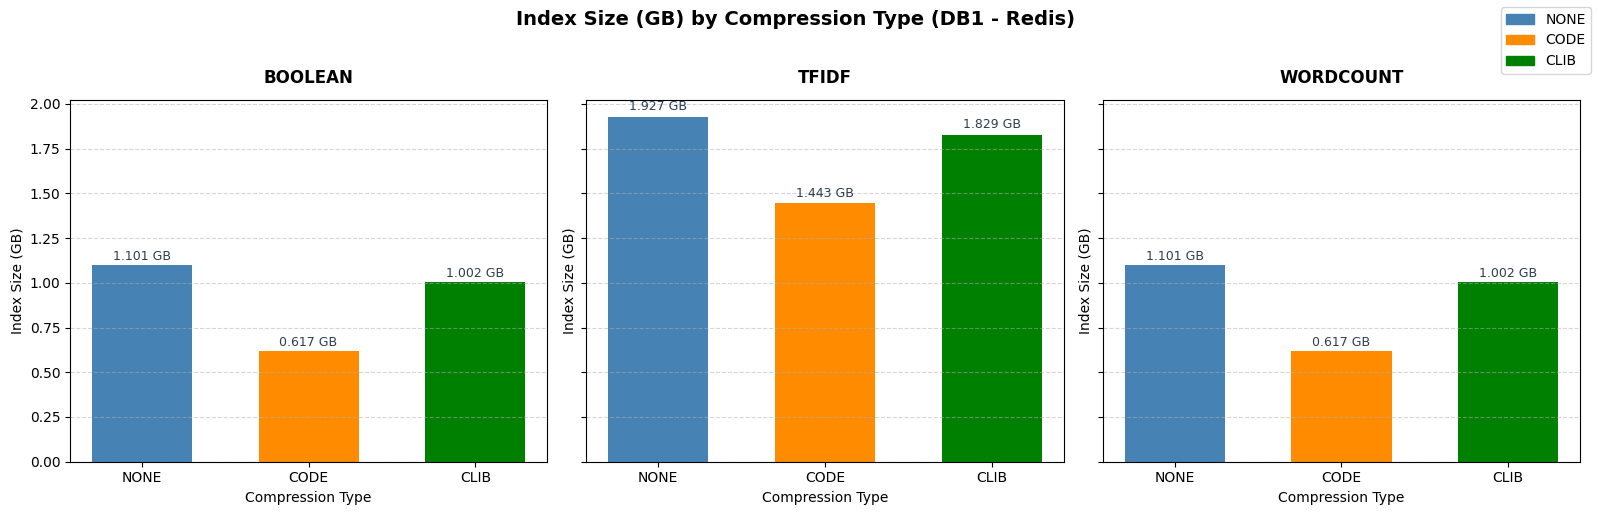

In [307]:
import pandas as pd
import matplotlib.pyplot as plt
import json
import re
import numpy as np

with open("index_metrics.json", "r") as f:
    data = json.load(f)
df = pd.DataFrame(data)
df = df[df["index_type"] == "self"].copy()
df["index_size_gb"] = df["index_size_mb"] / 1024.0


def extract_compression(path):
    if not isinstance(path, str):
        return "none"
    m = re.search(r"compress_([^/]+)", path, re.IGNORECASE)
    return m.group(1).lower() if m else "none"


df["compression"] = (
    df["index_directory"].apply(extract_compression).str.strip().str.lower()
)

grouped = (
    df.groupby(["info_type", "compression"], as_index=False)
    .agg(index_size_gb=("index_size_gb", "mean"))
    .sort_values(["info_type", "compression"])
)

print("Grouped rows:\n", grouped)  # debug

info_types = grouped["info_type"].unique()
comp_order = ["none", "code", "clib"]  # canonical order
colors = {"none": "steelblue", "code": "darkorange", "clib": "green"}
fallback_color = "#95A5A6"

fig, axes = plt.subplots(1, len(info_types), figsize=(16, 5), sharey=True)
if len(info_types) == 1:
    axes = [axes]

fig.suptitle(
    "Index Size (GB) by Compression Type (DB1 - Redis)",
    fontsize=14,
    weight="bold",
    y=1.02,
)

for ax, info in zip(axes, info_types):
    sub = grouped[grouped["info_type"] == info]

    # Build labels and values in canonical comp_order but only for comps present
    present_comps = [c for c in comp_order if c in sub["compression"].values]
    labels = [c.upper() for c in present_comps]
    values = [
        float(sub[sub["compression"] == c]["index_size_gb"].values[0])
        for c in present_comps
    ]
    bar_colors = [colors.get(c, fallback_color) for c in present_comps]

    x = np.arange(len(labels))
    bars = ax.bar(x, values, color=bar_colors, width=0.6)  # no edgecolor

    # add numeric labels
    max_val = max(values) if values else 1
    for i, bar in enumerate(bars):
        h = values[i]
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            h + 0.01 * max_val,
            f"{h:.3f} GB",
            ha="center",
            va="bottom",
            fontsize=9,
            color="#2C3E50",
        )

    ax.set_title(info, pad=12, weight="bold")
    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.set_xlabel("Compression Type")
    ax.set_ylabel("Index Size (GB)")
    ax.grid(axis="y", linestyle="--", alpha=0.5)

all_present = sorted(
    grouped["compression"].unique(),
    key=lambda x: comp_order.index(x) if x in comp_order else 99,
)
handles = [
    plt.Rectangle((0, 0), 1, 1, color=colors.get(c, fallback_color))
    for c in all_present
]
fig.legend(handles, [c.upper() for c in all_present], loc="upper right")

plt.tight_layout()
plt.show()

         info  dstore query_type          avg          p95          p99
0     BOOLEAN  CUSTOM    BOOLEAN  3627.825000   4674.49375   4824.32515
1     BOOLEAN  CUSTOM       EDGE  2997.883200   4652.42420   4672.54404
2     BOOLEAN  CUSTOM    GROUPED  9567.041750  12459.29760  12993.09792
3     BOOLEAN  CUSTOM      MIXED  4152.859000   5371.22590   5597.23078
4     BOOLEAN  CUSTOM     NESTED  8169.953750   9808.28585   9996.22757
..        ...     ...        ...          ...          ...          ...
58  WORDCOUNT     DB2    GROUPED     0.246250      0.28520      0.29144
59  WORDCOUNT     DB2      MIXED     0.198250      0.23575      0.24235
60  WORDCOUNT     DB2     NESTED     0.213750      0.22650      0.22770
61  WORDCOUNT     DB2     PHRASE     0.152667      0.16410      0.16562
62  WORDCOUNT     DB2       TERM     0.137500      0.14155      0.14191

[63 rows x 6 columns]


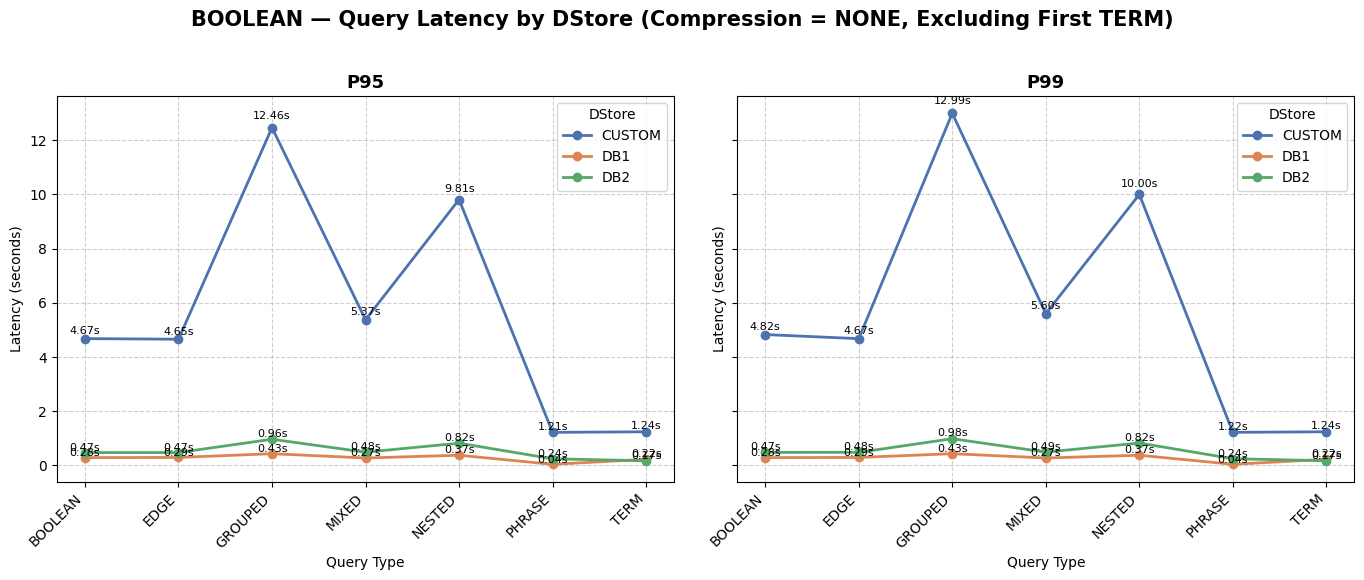

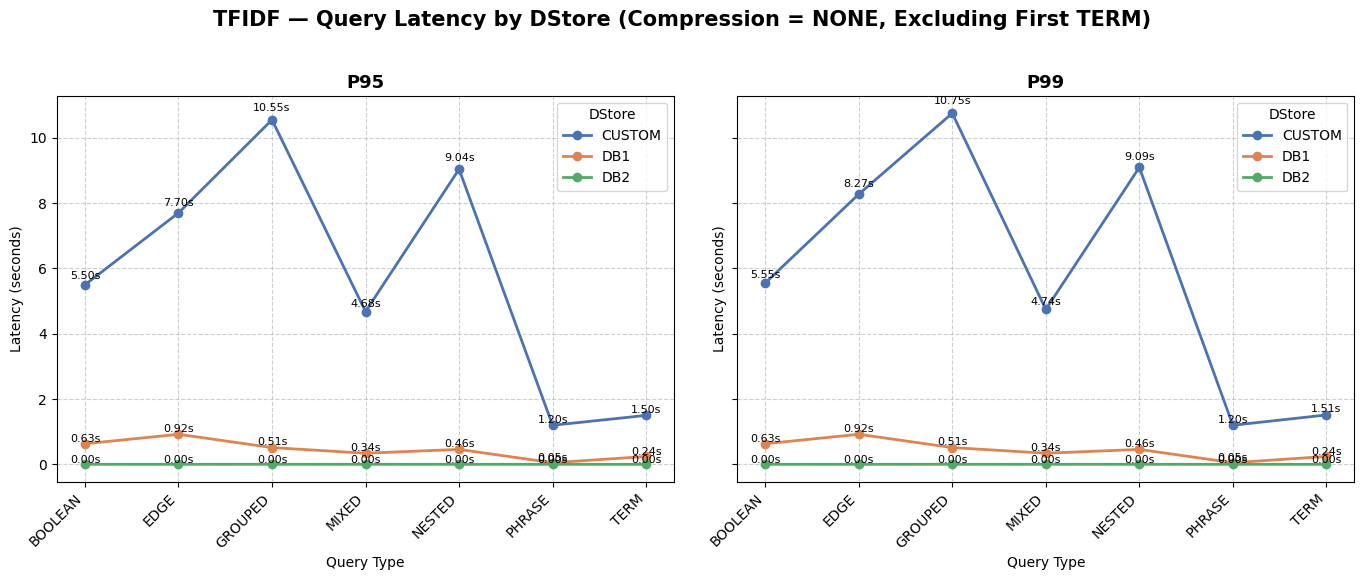

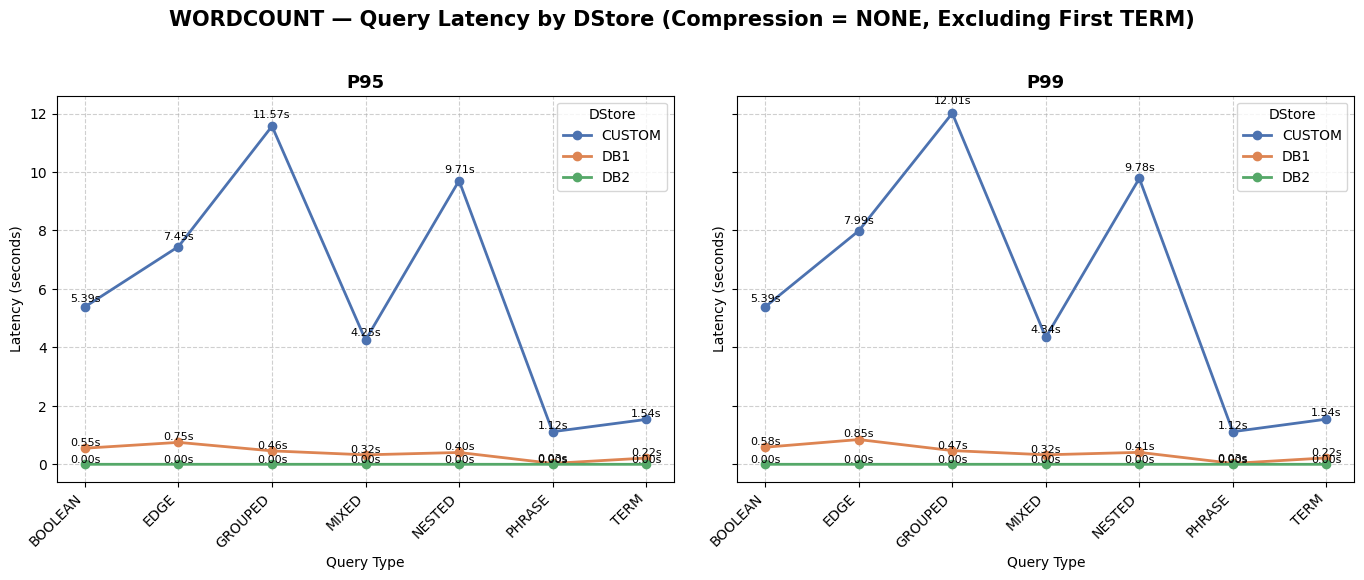

In [309]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv("query_latency_log.csv", header=None)

df.columns = [
    "timestamp",
    "index_type",
    "info",
    "dstore",
    "compr",
    "qproc",
    "optim",
    "query",
    "query_type",
    "run_id",
    "latency_ms",
    "current_mem_kb",
    "peak_mem_kb",
]

df = df[
    (df["index_type"].str.lower() == "self")
    & (df["optim"].str.lower() == "null")
    & (df["dstore"].str.lower().isin(["custom", "db1", "db2"]))
    & (df["compr"].str.lower() == "none")
]

for col in ["info", "compr", "query_type", "dstore"]:
    df[col] = df[col].astype(str).str.strip().str.upper()

df["latency_ms"] = pd.to_numeric(df["latency_ms"], errors="coerce")
df = df.dropna(subset=["latency_ms"])
df = df.sort_values("timestamp")

first_term_query = (
    df[df["query_type"] == "TERM"].groupby(["info", "dstore"], group_keys=False).head(1)
)
df_excluding_first = df.drop(first_term_query.index)
agg = (
    df_excluding_first.groupby(["info", "dstore", "query_type"])["latency_ms"]
    .agg(
        avg="mean",
        p95=lambda x: x.quantile(0.95),
        p99=lambda x: x.quantile(0.99),
    )
    .reset_index()
)

print(agg)

info_types = ["BOOLEAN", "TFIDF", "WORDCOUNT"]
colors = {"CUSTOM": "#4C72B0", "DB1": "#DD8452", "DB2": "#55A868"}  # added DB2 color
metrics = ["p95", "p99"]

for info in info_types:
    sub_info = agg[agg["info"] == info]
    if sub_info.empty:
        continue

    fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)
    fig.suptitle(
        f"{info} — Query Latency by DStore (Compression = NONE, Excluding First TERM)",
        fontsize=15,
        weight="bold",
    )

    for ax, metric in zip(axes, metrics):
        query_types = sorted(sub_info["query_type"].unique())
        x = np.arange(len(query_types))

        for dstore in ["CUSTOM", "DB1", "DB2"]:
            sub = sub_info[sub_info["dstore"] == dstore].sort_values("query_type")
            if sub.empty:
                continue

            y_vals = sub[metric] / 1000.0  # Convert ms → seconds

            ax.plot(
                x,
                y_vals,
                label=dstore,
                color=colors[dstore],
                marker="o",
                linewidth=2,
                markersize=6,
            )

            # Value labels
            for i, val in enumerate(y_vals):
                ax.text(
                    x[i],
                    val + 0.02 * val,
                    f"{val:.2f}s",
                    ha="center",
                    va="bottom",
                    fontsize=8,
                )

        ax.set_xticks(x)
        ax.set_xticklabels(query_types, rotation=45, ha="right")
        ax.set_xlabel("Query Type")
        ax.set_ylabel("Latency (seconds)")
        ax.set_title(metric.upper(), fontsize=13, weight="bold")
        ax.grid(True, linestyle="--", alpha=0.6)
        ax.legend(title="DStore", frameon=True)

    plt.tight_layout(pad=2.0)
    plt.show()

#### c). Plot.AB for z=n compares two compression methods on the postings list, one simple code (z=1) and an off-the-shelf library (z=2).

In [ ]:
run_index_helper(
    "logs/index_xz_stdout.log",
    "logs/index_xz_stderr.log",
    "configs/config_xz.json",
)

Output saved to logs/index_xz_stdout.log and logs/index_xz_stderr.log


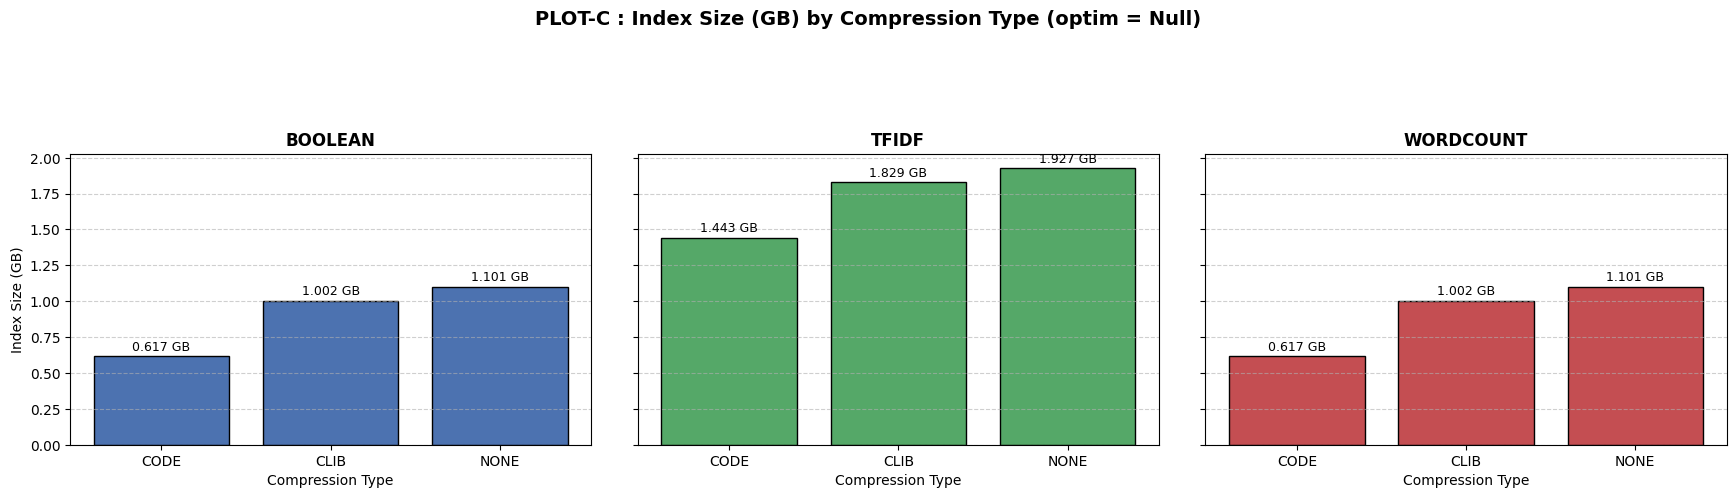

In [314]:
import pandas as pd
import matplotlib.pyplot as plt
import json
import re

with open("index_metrics.json", "r") as f:
    data = json.load(f)

df = pd.DataFrame(data)
df["index_size_gb"] = df["index_size_mb"] / 1024


def extract_compression(path):
    if not isinstance(path, str):
        return "none"
    match = re.search(r"compress_([^/]+)", path)
    return match.group(1).upper() if match else "NONE"


def extract_optim(path):
    if not isinstance(path, str):
        return "none"
    match = re.search(r"optim_([^/]+)", path)
    return match.group(1).capitalize() if match else "None"


def extract_dstore(path):
    if not isinstance(path, str):
        return "unknown"
    match = re.search(r"indexes_([^/]+)", path)
    return match.group(1).lower() if match else "unknown"


df["dstore"] = df["index_directory"].apply(extract_dstore)


df["compression"] = df["index_directory"].apply(extract_compression)
df["optim"] = df["index_directory"].apply(extract_optim)


df = df[(df["optim"] == "Null") & (df["dstore"] == "custom")]
info_groups = df.groupby("info_type")
fig, axes = plt.subplots(1, len(info_groups), figsize=(18, 5), sharey=True)
fig.suptitle(
    "PLOT-C : Index Size (GB) by Compression Type (optim = Null)",
    fontsize=14,
    weight="bold",
    y=1.04,
)

colors = ["#4C72B0", "#55A868", "#C44E52"]

for ax, (info_type, group), color in zip(axes, info_groups, colors):
    group = group.sort_values("index_size_gb", ascending=True)

    bars = ax.bar(
        group["compression"], group["index_size_gb"], color=color, edgecolor="black"
    )

    # Add labels above bars
    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height + 0.02,
            f"{height:.3f} GB",
            ha="center",
            va="bottom",
            fontsize=9,
        )

    ax.set_title(info_type, fontsize=12, weight="bold")
    ax.set_xlabel("Compression Type")
    ax.grid(axis="y", linestyle="--", alpha=0.6)

axes[0].set_ylabel("Index Size (GB)")
plt.tight_layout(pad=3.0)
plt.show()

In [ ]:
run_query_helper(
    "./logs/query_xz_stdout.log",
    "./logs/query_xz_stderr.log",
    "configs/config_xz.json",
)

Output saved to ./logs/query_xz_stdout.log and ./logs/query_xz_stderr.log


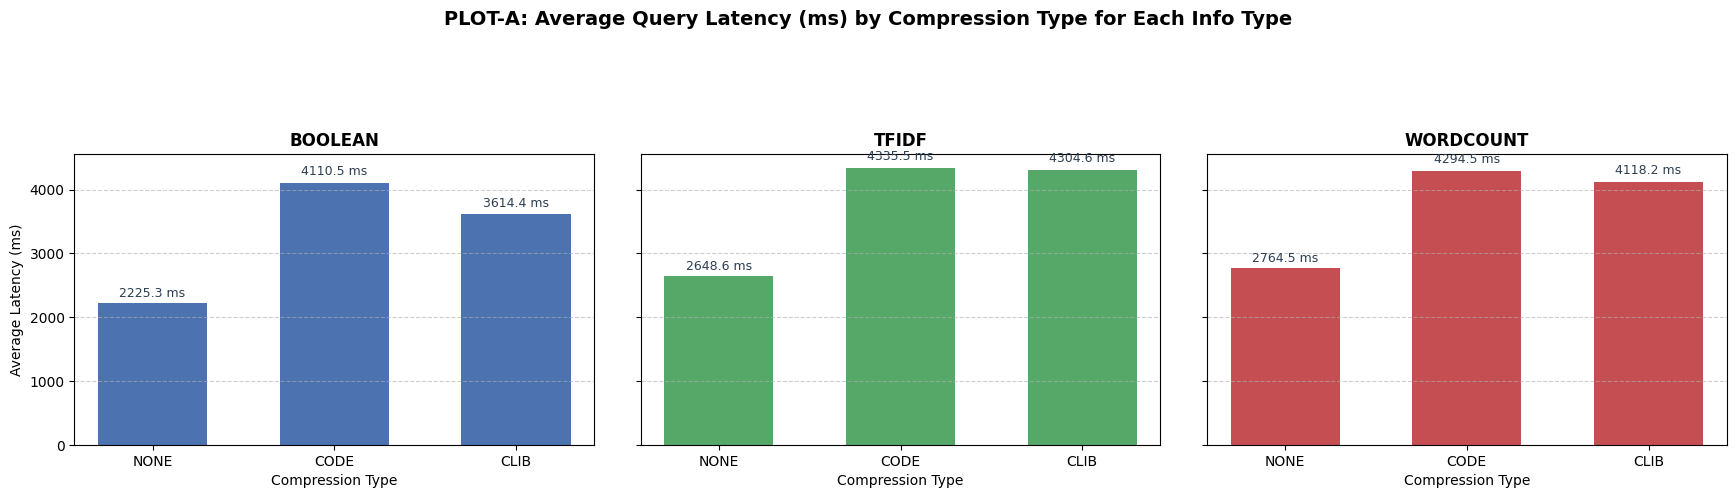

In [317]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("query_latency_log.csv", header=None)

df.columns = [
    "timestamp",
    "index_type",
    "info",
    "dstore",
    "compr",
    "qproc",
    "optim",
    "query",
    "query_type",
    "run_id",
    "latency_ms",
    "current_mem_kb",
    "peak_mem_kb",
]


df = df[df["index_type"] == "self"]


df["info"] = df["info"].str.strip().str.upper()
df["compr"] = df["compr"].str.strip().str.upper()
df["latency_ms"] = pd.to_numeric(df["latency_ms"], errors="coerce")


avg_latency = df.groupby(["info", "compr"], as_index=False)["latency_ms"].mean()


info_groups = avg_latency.groupby("info")
colors = ["#4C72B0", "#55A868", "#C44E52"]  # blue, green, red

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
fig.suptitle(
    "PLOT-A: Average Query Latency (ms) by Compression Type for Each Info Type",
    fontsize=14,
    weight="bold",
    y=1.04,
)

for ax, (info_type, group), color in zip(axes, info_groups, colors):
    # Sort compression order for consistency
    order = ["NONE", "CODE", "CLIB"]
    group["compr"] = pd.Categorical(group["compr"], categories=order, ordered=True)
    group = group.sort_values("compr")

    # Plot bars
    bars = ax.bar(
        group["compr"],
        group["latency_ms"],
        color=color,
        edgecolor="none",
        width=0.6,
    )

    # Add labels above bars
    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height + (0.02 * height),
            f"{height:.1f} ms",
            ha="center",
            va="bottom",
            fontsize=9,
            fontweight="medium",
            color="#2C3E50",
        )

    ax.set_title(info_type, fontsize=12, weight="bold")
    ax.set_xlabel("Compression Type")
    ax.grid(axis="y", linestyle="--", alpha=0.6)

axes[0].set_ylabel("Average Latency (ms)")

plt.tight_layout(pad=3.0)
plt.show()

        info compr          avg         p95          p99
0    BOOLEAN  CLIB  3614.408741  7016.11990  12862.32820
1    BOOLEAN  CODE  4110.490815  8781.07530  12680.87362
2    BOOLEAN  NONE  2225.342852  8383.71710  12910.71455
3      TFIDF  CLIB  4304.574259  7576.75740  18166.02712
4      TFIDF  CODE  4335.514963  7952.26640  17805.00440
5      TFIDF  NONE  2648.554204  8495.85885  10684.63834
6  WORDCOUNT  CLIB  4118.158741  8100.02220  13641.51984
7  WORDCOUNT  CODE  4294.504481  9176.73560  12342.11882
8  WORDCOUNT  NONE  2764.528407  8662.09100  27152.14980


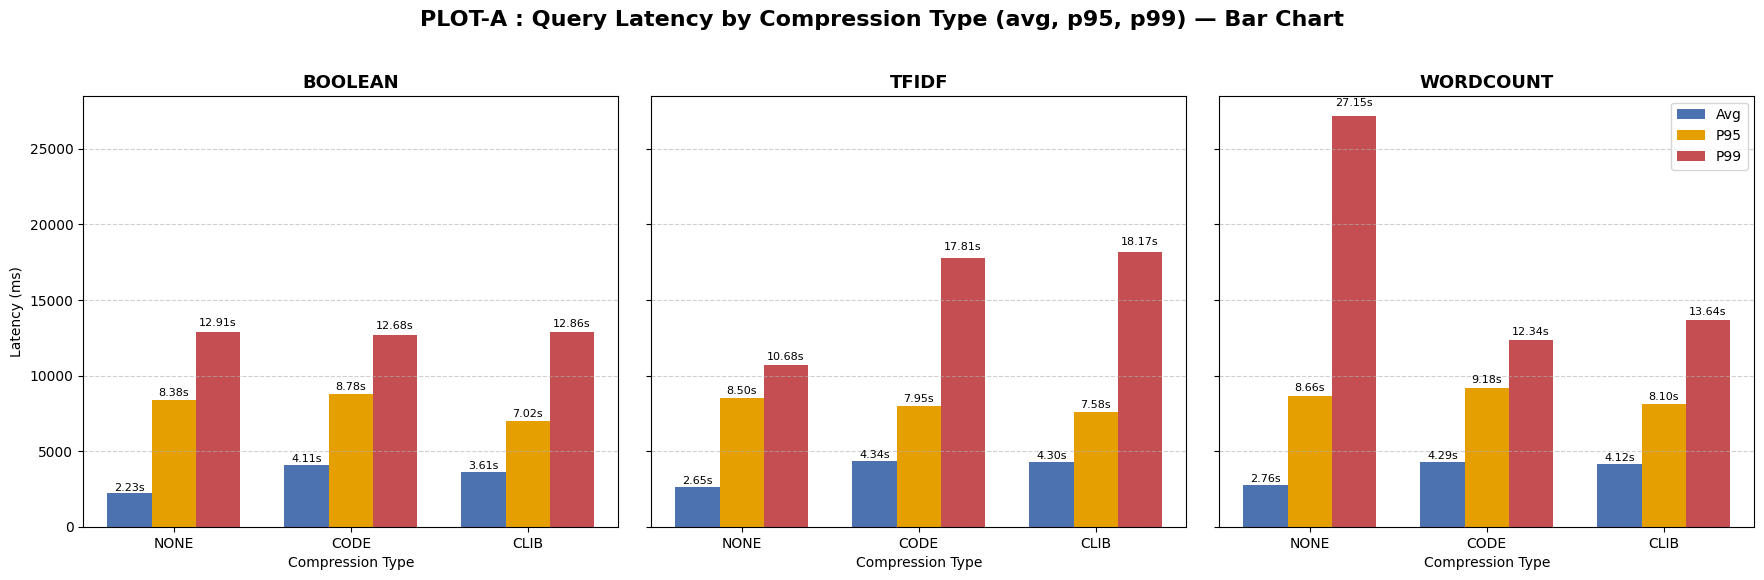

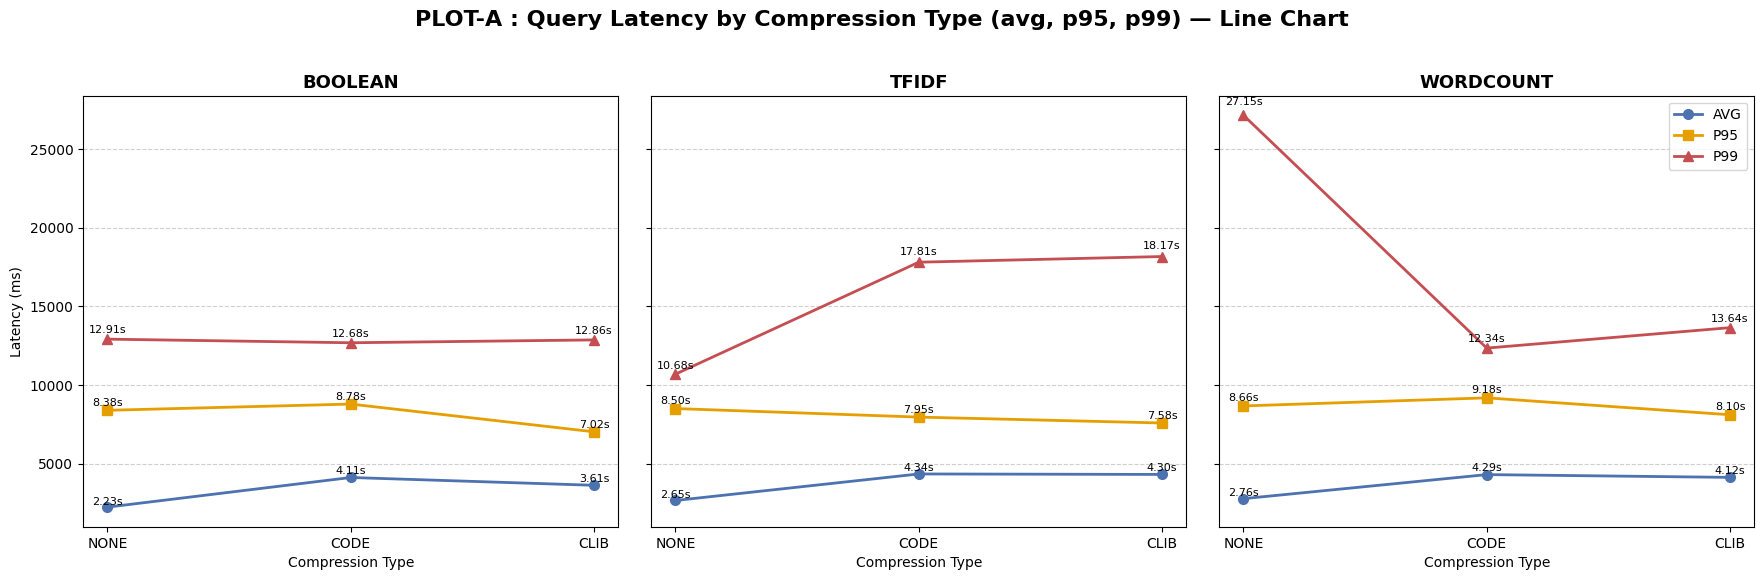

In [318]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


df = pd.read_csv("query_latency_log.csv", header=None)

df.columns = [
    "timestamp",
    "index_type",
    "info",
    "dstore",
    "compr",
    "qproc",
    "optim",
    "query",
    "query_type",
    "run_id",
    "latency_ms",
    "current_mem_kb",
    "peak_mem_kb",
]


df = df[df["index_type"] == "self"]


df["compr"] = df["compr"].astype(str).str.strip().str.upper()
df["info"] = df["info"].astype(str).str.strip().str.upper()


df["latency_ms"] = pd.to_numeric(df["latency_ms"], errors="coerce")
df = df.dropna(subset=["latency_ms"])


agg = (
    df.groupby(["info", "compr"])["latency_ms"]
    .agg(
        avg="mean",
        p95=lambda x: x.quantile(0.95),
        p99=lambda x: x.quantile(0.99),
    )
    .reset_index()
)

print(agg)

# --- Settings ---
info_types = ["BOOLEAN", "TFIDF", "WORDCOUNT"]
colors = {"NONE": "#4C72B0", "CODE": "#DD8452", "CLIB": "#55A868"}
metrics = ["avg", "p95", "p99"]


fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)
fig.suptitle(
    "PLOT-A : Query Latency by Compression Type (avg, p95, p99) — Bar Chart",
    fontsize=16,
    weight="bold",
)

for ax, info in zip(axes, info_types):
    sub = agg[agg["info"] == info].sort_values(
        "compr", key=lambda s: s.map({"NONE": 0, "CODE": 1, "CLIB": 2})
    )

    x = np.arange(len(sub))
    width = 0.25

    bars_avg = ax.bar(x - width, sub["avg"], width, label="Avg", color="#4C72B0")
    bars_p95 = ax.bar(x, sub["p95"], width, label="P95", color="#E69F00")
    bars_p99 = ax.bar(x + width, sub["p99"], width, label="P99", color="#C44E52")

    ax.set_xticks(x)
    ax.set_xticklabels(sub["compr"], fontsize=10)
    ax.set_title(info, fontsize=13, weight="bold")
    ax.set_xlabel("Compression Type")
    ax.grid(axis="y", linestyle="--", alpha=0.6)

    # Add labels (in seconds)
    for bars in [bars_avg, bars_p95, bars_p99]:
        for bar in bars:
            height = bar.get_height()
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                height + (0.02 * height),
                f"{height/1000:.2f}s",  # convert ms → seconds
                ha="center",
                va="bottom",
                fontsize=8,
            )

axes[0].set_ylabel("Latency (ms)")
axes[-1].legend(loc="upper right", frameon=True)

plt.tight_layout(pad=2.0)
plt.show()


fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)
fig.suptitle(
    "PLOT-A : Query Latency by Compression Type (avg, p95, p99) — Line Chart",
    fontsize=16,
    weight="bold",
)

markers = {"avg": "o", "p95": "s", "p99": "^"}
colors_line = {"avg": "#4C72B0", "p95": "#E69F00", "p99": "#C44E52"}

for ax, info in zip(axes, info_types):
    sub = agg[agg["info"] == info].sort_values(
        "compr", key=lambda s: s.map({"NONE": 0, "CODE": 1, "CLIB": 2})
    )

    x = np.arange(len(sub))

    for metric in metrics:
        ax.plot(
            x,
            sub[metric],
            label=metric.upper(),
            color=colors_line[metric],
            marker=markers[metric],
            linewidth=2,
            markersize=7,
        )
        # Add text labels (in seconds)
        for i, val in enumerate(sub[metric]):
            ax.text(
                x[i],
                val + 0.02 * val,
                f"{val/1000:.2f}s",  # convert ms → seconds
                ha="center",
                va="bottom",
                fontsize=8,
            )

    ax.set_xticks(x)
    ax.set_xticklabels(sub["compr"], fontsize=10)
    ax.set_title(info, fontsize=13, weight="bold")
    ax.set_xlabel("Compression Type")
    ax.grid(axis="y", linestyle="--", alpha=0.6)

axes[0].set_ylabel("Latency (ms)")
axes[-1].legend(loc="upper right", frameon=True)

plt.tight_layout(pad=2.0)
plt.show()

         info compr query_type           avg          p95          p99
0     BOOLEAN  CLIB    BOOLEAN   2664.328500   3717.00005   3958.84081
1     BOOLEAN  CLIB       EDGE   2420.758600   3781.04200   3820.87240
2     BOOLEAN  CLIB    GROUPED   6276.820500   7976.17960   8337.36952
3     BOOLEAN  CLIB      MIXED   2947.569125   3891.59465   4165.22773
4     BOOLEAN  CLIB     NESTED   6395.203250   8060.92235   8417.26127
..        ...   ...        ...           ...          ...          ...
58  WORDCOUNT  NONE    GROUPED   3806.007850   9379.72985  11574.51637
59  WORDCOUNT  NONE      MIXED   1888.331050   3870.47220   4267.56004
60  WORDCOUNT  NONE     NESTED   3328.145000   9183.52000   9679.22240
61  WORDCOUNT  NONE     PHRASE    654.789733   1188.40740   1209.41748
62  WORDCOUNT  NONE       TERM  15674.508786  85960.69695  87006.45699

[63 rows x 6 columns]


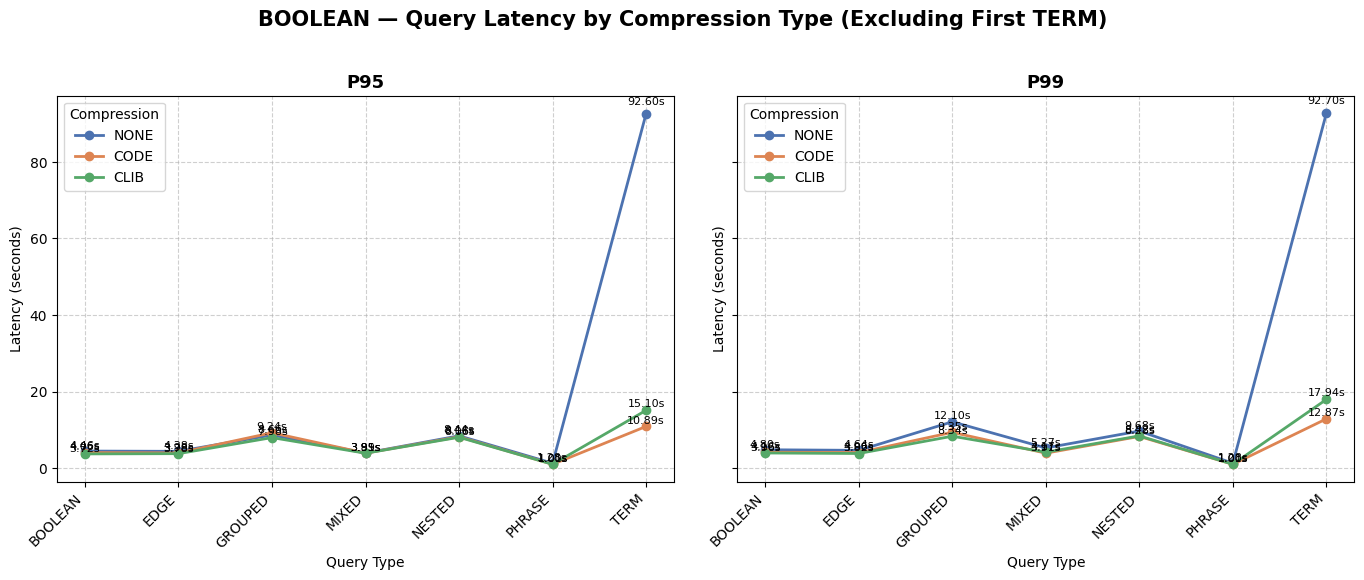

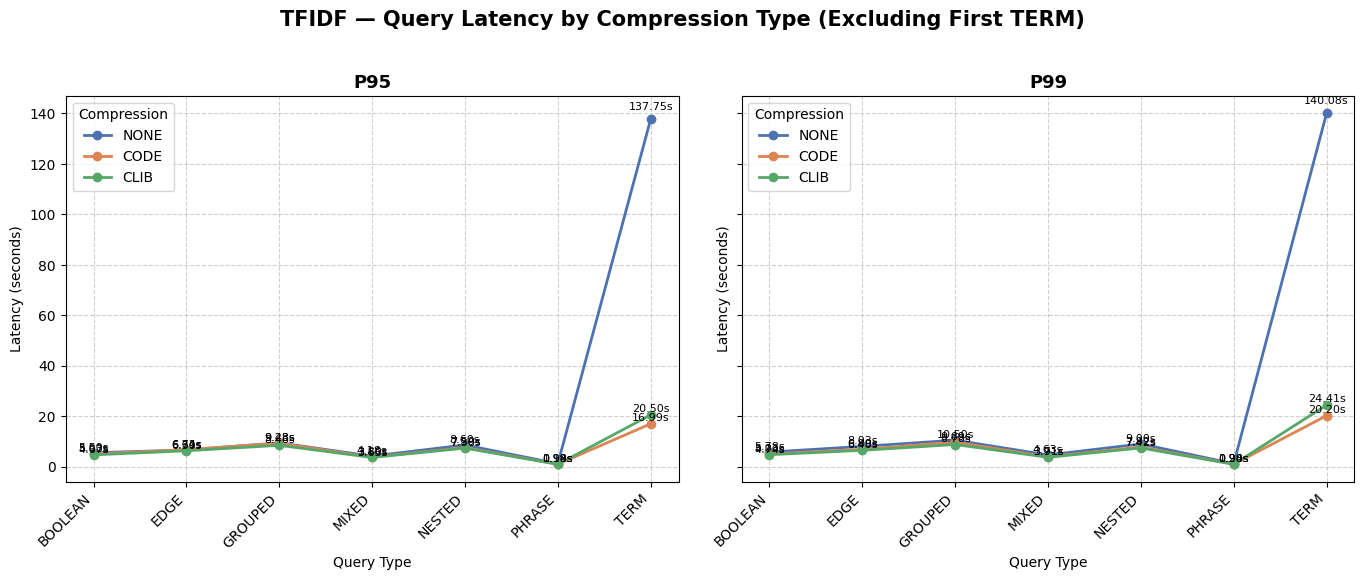

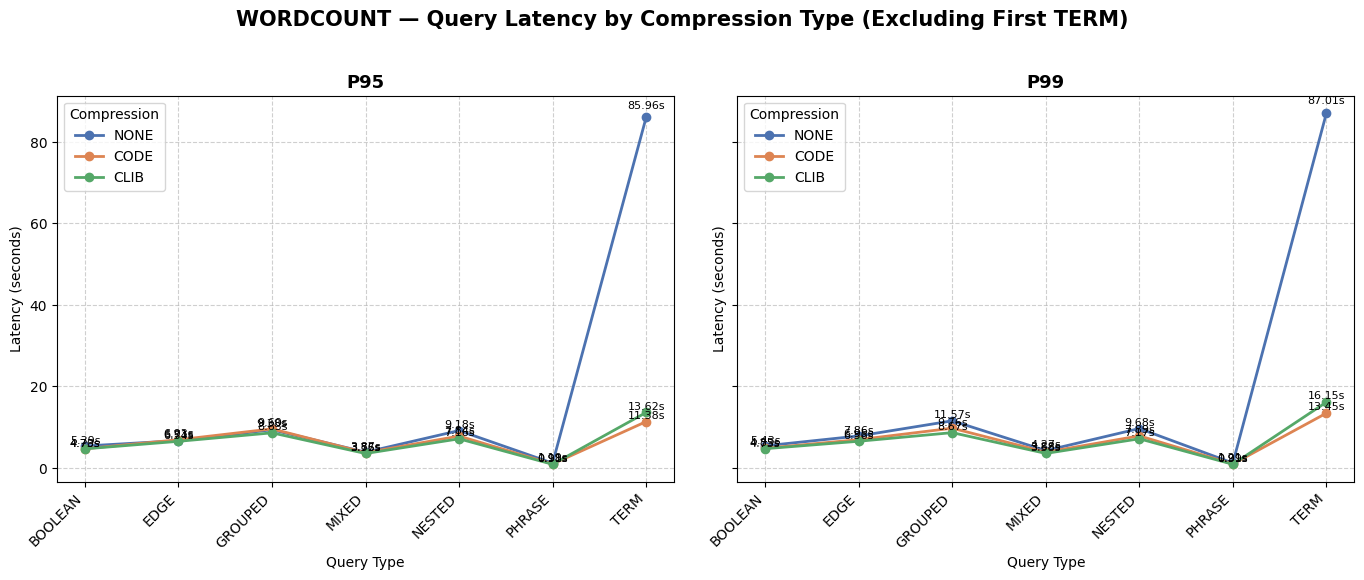

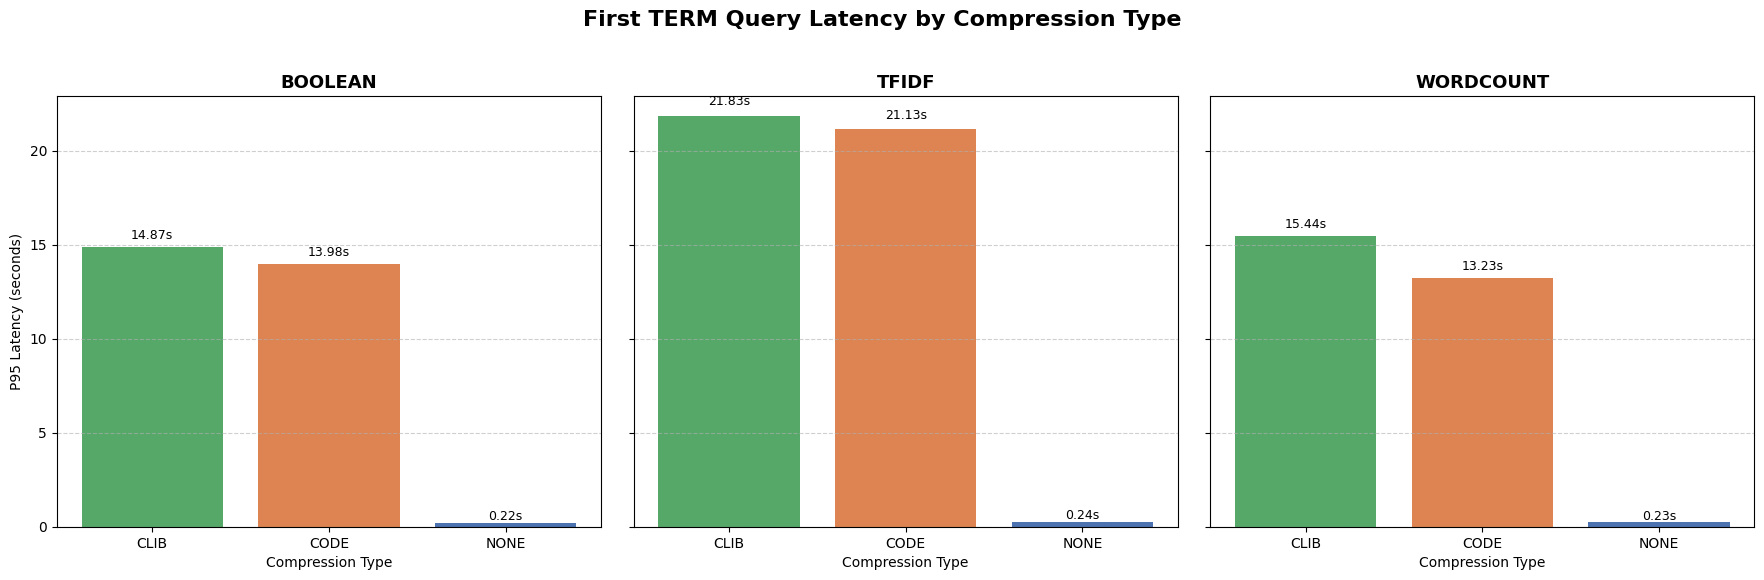

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


df = pd.read_csv("query_latency_log.csv", header=None)


df.columns = [
    "timestamp",
    "index_type",
    "info",
    "dstore",
    "compr",
    "qproc",
    "optim",
    "query",
    "query_type",
    "run_id",
    "latency_ms",
    "current_mem_kb",
    "peak_mem_kb",
]


df = df[df["index_type"].str.lower() == "self"]


for col in ["info", "compr", "query_type"]:
    df[col] = df[col].astype(str).str.strip().str.upper()

df["latency_ms"] = pd.to_numeric(df["latency_ms"], errors="coerce")
df = df.dropna(subset=["latency_ms"])


df = df.sort_values("timestamp")

first_term_query = (
    df[df["query_type"] == "TERM"]
    .groupby(["info", "compr"], group_keys=False)
    .head(1)  # pick first per (info, compr)
)

df_excluding_first = df.drop(first_term_query.index)

agg = (
    df_excluding_first.groupby(["info", "compr", "query_type"])["latency_ms"]
    .agg(
        avg="mean",
        p95=lambda x: x.quantile(0.95),
        p99=lambda x: x.quantile(0.99),
    )
    .reset_index()
)

agg.to_csv("output.csv")
print(agg)
first_term_metrics = (
    first_term_query.groupby(["info", "compr"])["latency_ms"]
    .agg(
        avg="mean",
        p95=lambda x: x.quantile(0.95),
        p99=lambda x: x.quantile(0.99),
    )
    .reset_index()
)

info_types = ["BOOLEAN", "TFIDF", "WORDCOUNT"]
colors = {"NONE": "#4C72B0", "CODE": "#DD8452", "CLIB": "#55A868"}
metrics = ["p95", "p99"]

for info in info_types:
    sub_info = agg[agg["info"] == info]
    if sub_info.empty:
        continue

    fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)
    fig.suptitle(
        f"{info} — Query Latency by Compression Type (Excluding First TERM)",
        fontsize=15,
        weight="bold",
    )

    for ax, metric in zip(axes, metrics):
        query_types = sorted(sub_info["query_type"].unique())
        x = np.arange(len(query_types))

        for compr in ["NONE", "CODE", "CLIB"]:
            sub = sub_info[sub_info["compr"] == compr].sort_values("query_type")
            if sub.empty:
                continue

            y_vals = sub[metric] / 1000.0  # Convert to seconds

            ax.plot(
                x,
                y_vals,
                label=f"{compr}",
                color=colors[compr],
                marker="o",
                linewidth=2,
                markersize=6,
            )

            # Add labels
            for i, val in enumerate(y_vals):
                ax.text(
                    x[i],
                    val + 0.02 * val,
                    f"{val:.2f}s",
                    ha="center",
                    va="bottom",
                    fontsize=8,
                )

        ax.set_xticks(x)
        ax.set_xticklabels(query_types, rotation=45, ha="right")
        ax.set_xlabel("Query Type")
        ax.set_ylabel("Latency (seconds)")
        ax.set_title(metric.upper(), fontsize=13, weight="bold")
        ax.grid(True, linestyle="--", alpha=0.6)
        ax.legend(title="Compression", frameon=True)

    plt.tight_layout(pad=2.0)
    plt.show()


fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)
fig.suptitle("First TERM Query Latency by Compression Type", fontsize=16, weight="bold")

info_types = ["BOOLEAN", "TFIDF", "WORDCOUNT"]

for ax, info in zip(axes, info_types):
    sub = first_term_metrics[first_term_metrics["info"] == info]
    if sub.empty:
        ax.set_visible(False)
        continue

    # Convert latency to seconds
    y_vals = sub["p95"] / 1000.0

    bars = ax.bar(
        sub["compr"],
        y_vals,
        color=[colors.get(c, "#95A5A6") for c in sub["compr"]],
        edgecolor="none",
    )

    # Add labels in seconds
    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height + 0.02 * height,
            f"{height:.2f}s",
            ha="center",
            va="bottom",
            fontsize=9,
            weight="medium",
        )

    ax.set_title(info, fontsize=13, weight="bold")
    ax.set_xlabel("Compression Type")
    ax.grid(axis="y", linestyle="--", alpha=0.6)

axes[0].set_ylabel("P95 Latency (seconds)")
plt.tight_layout(pad=2.0)
plt.show()

        info compr          avg  throughput_qps
0    BOOLEAN  CLIB  3614.408741        0.276670
1    BOOLEAN  CODE  4110.490815        0.243280
2    BOOLEAN  NONE  2225.342852        0.449369
3      TFIDF  CLIB  4304.574259        0.232311
4      TFIDF  CODE  4335.514963        0.230653
5      TFIDF  NONE  2648.554204        0.377564
6  WORDCOUNT  CLIB  4118.158741        0.242827
7  WORDCOUNT  CODE  4294.504481        0.232856
8  WORDCOUNT  NONE  2764.528407        0.361725


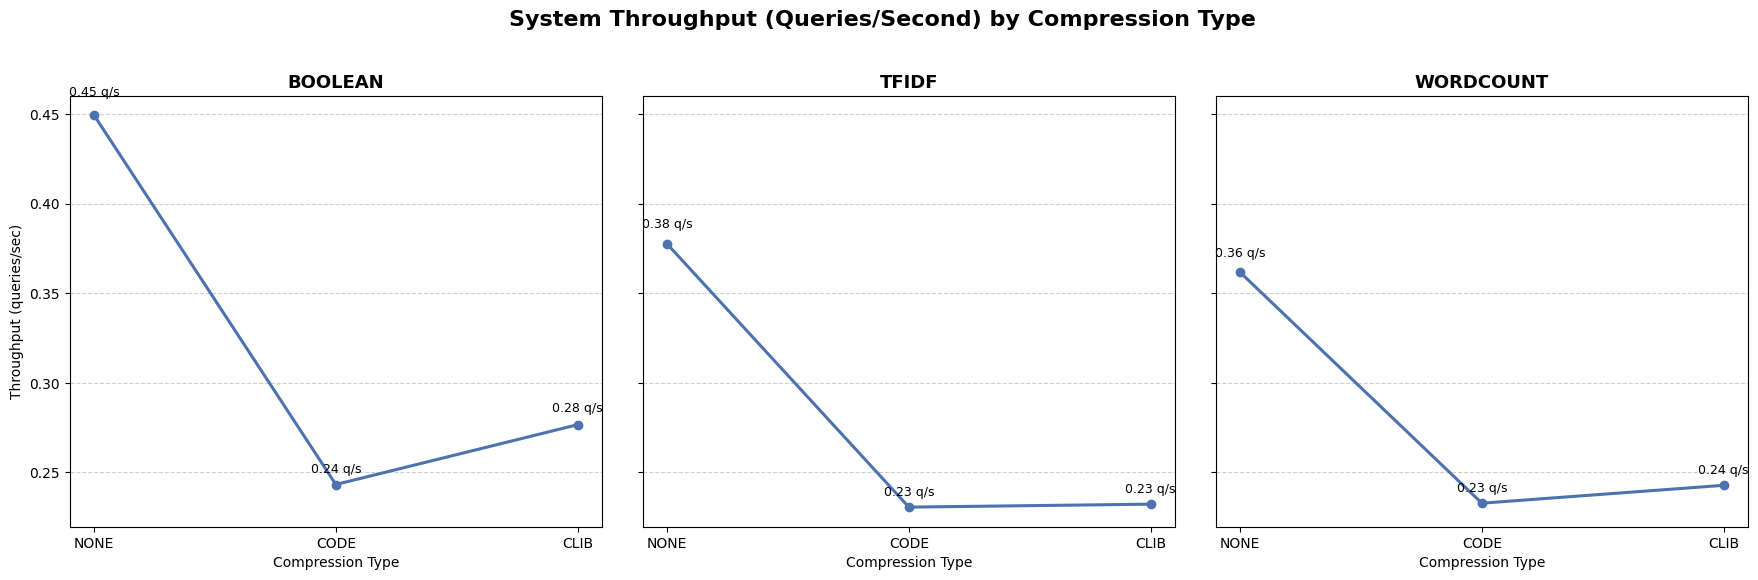

In [321]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


df = pd.read_csv("query_latency_log.csv", header=None)

df.columns = [
    "timestamp",
    "index_type",
    "info",
    "dstore",
    "compr",
    "qproc",
    "optim",
    "query",
    "query_type",
    "run_id",
    "latency_ms",
    "current_mem_kb",
    "peak_mem_kb",
]

df = df[df["index_type"].str.lower() == "self"]


for col in ["info", "compr"]:
    df[col] = df[col].astype(str).str.strip().str.upper()

df["latency_ms"] = pd.to_numeric(df["latency_ms"], errors="coerce")
df = df.dropna(subset=["latency_ms"])


agg = df.groupby(["info", "compr"])["latency_ms"].agg(avg="mean").reset_index()


agg["throughput_qps"] = 1000.0 / agg["avg"]  # 1000 ms → 1 second

print(agg)


info_types = ["BOOLEAN", "TFIDF", "WORDCOUNT"]
colors = {"NONE": "#4C72B0", "CODE": "#DD8452", "CLIB": "#55A868"}


fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)
fig.suptitle(
    "System Throughput (Queries/Second) by Compression Type", fontsize=16, weight="bold"
)

for ax, info in zip(axes, info_types):
    sub = agg[agg["info"] == info].sort_values(
        "compr", key=lambda s: s.map({"NONE": 0, "CODE": 1, "CLIB": 2})
    )

    x = np.arange(len(sub))
    y = sub["throughput_qps"]

    ax.plot(x, y, marker="o", linestyle="-", linewidth=2.2, color="#4C72B0")

    # Add point labels
    for xi, yi, label in zip(x, y, sub["compr"]):
        ax.text(
            xi,
            yi + 0.02 * yi,
            f"{yi:.2f} q/s",
            ha="center",
            va="bottom",
            fontsize=9,
        )

    ax.set_xticks(x)
    ax.set_xticklabels(sub["compr"], fontsize=10)
    ax.set_xlabel("Compression Type")
    ax.set_title(info, fontsize=13, weight="bold")
    ax.grid(axis="y", linestyle="--", alpha=0.6)

axes[0].set_ylabel("Throughput (queries/sec)")
plt.tight_layout(pad=2.0)
plt.show()

### d). Plot.A for i=0/1 implements index optimization like skipping with pointers.

In [ ]:
run_index_helper(
    "logs/index_i_stdout.log",
    "logs/index_i_stderr.log",
    "configs/config_i.json",
)

Output saved to logs/index_i_stdout.log and logs/index_i_stderr.log


In [ ]:
run_query_helper(
    "./logs/query_i_stdout.log",
    "./logs/query_i_stderr.log",
    "configs/config_i.json",
)

Output saved to ./logs/query_i_stdout.log and ./logs/query_i_stderr.log


        info compr          avg         p95          p99
0    BOOLEAN  CLIB  3939.913370  8455.20465  16649.56531
1    BOOLEAN  CODE  4116.158426  9123.17355  13655.23239
2    BOOLEAN  NONE  2785.250022  8479.79590  30296.78526
3      TFIDF  CLIB  4462.152481  8126.27980  23504.22010
4      TFIDF  CODE  4515.040167  8846.23590  21059.92975
5      TFIDF  NONE  3293.861407  8574.94740  38982.18198
6  WORDCOUNT  CLIB  4168.668796  8573.33905  16074.27574
7  WORDCOUNT  CODE  4346.232333  9421.50110  13580.63813
8  WORDCOUNT  NONE  3390.445778  8979.82205  37527.93465


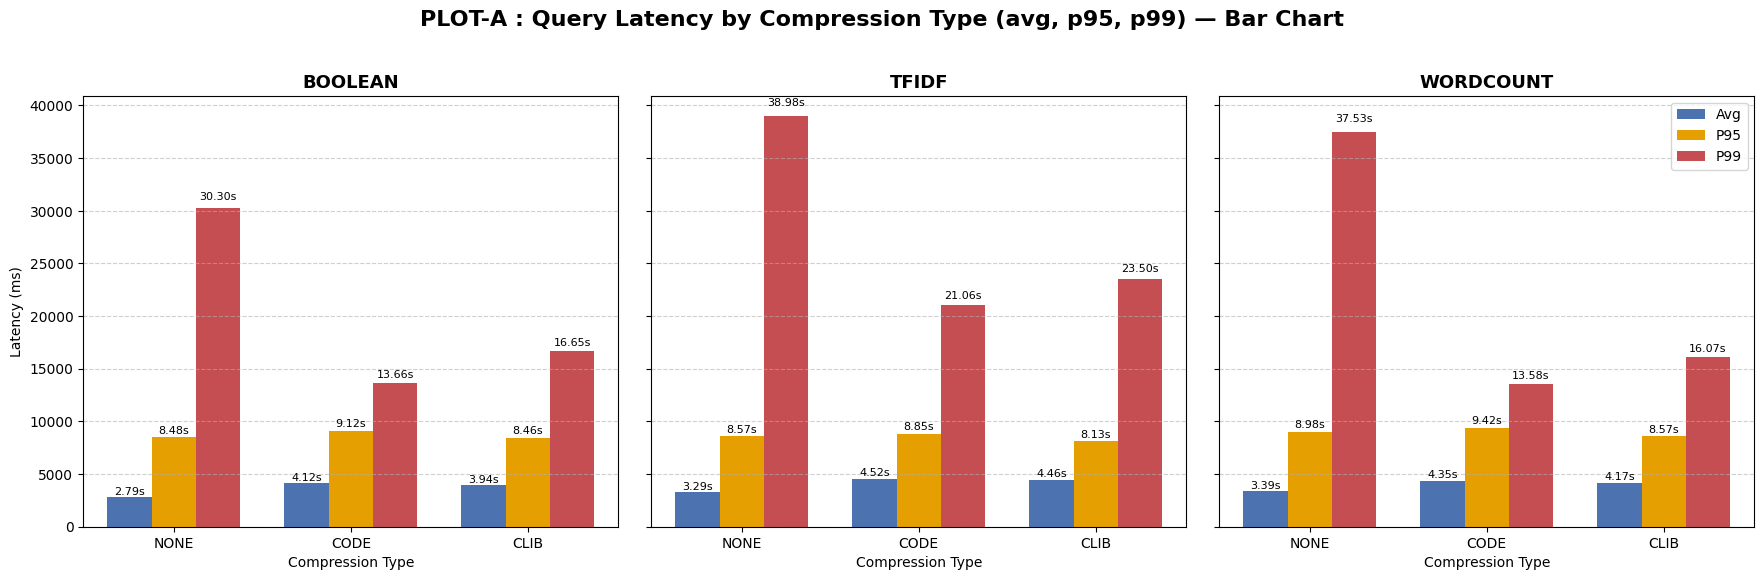

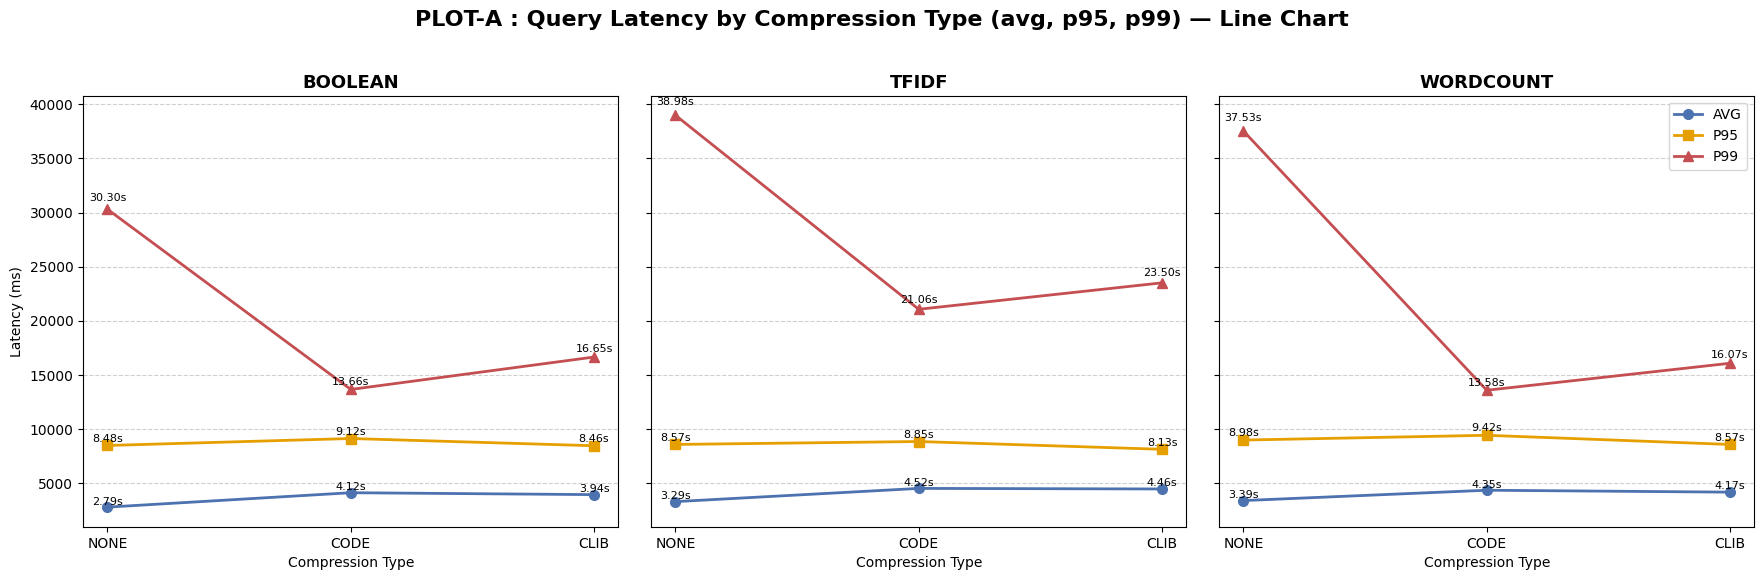

In [322]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


df = pd.read_csv("query_latency_log.csv", header=None)


df.columns = [
    "timestamp",
    "index_type",
    "info",
    "dstore",
    "compr",
    "qproc",
    "optim",
    "query",
    "query_type",
    "run_id",
    "latency_ms",
    "current_mem_kb",
    "peak_mem_kb",
]


df = df[df["index_type"] == "self"]


df["compr"] = df["compr"].astype(str).str.strip().str.upper()
df["info"] = df["info"].astype(str).str.strip().str.upper()


df["latency_ms"] = pd.to_numeric(df["latency_ms"], errors="coerce")
df = df.dropna(subset=["latency_ms"])


agg = (
    df.groupby(["info", "compr"])["latency_ms"]
    .agg(
        avg="mean",
        p95=lambda x: x.quantile(0.95),
        p99=lambda x: x.quantile(0.99),
    )
    .reset_index()
)

print(agg)

info_types = ["BOOLEAN", "TFIDF", "WORDCOUNT"]
colors = {"NONE": "#4C72B0", "CODE": "#DD8452", "CLIB": "#55A868"}
metrics = ["avg", "p95", "p99"]


fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)
fig.suptitle(
    "PLOT-A : Query Latency by Compression Type (avg, p95, p99) — Bar Chart",
    fontsize=16,
    weight="bold",
)

for ax, info in zip(axes, info_types):
    sub = agg[agg["info"] == info].sort_values(
        "compr", key=lambda s: s.map({"NONE": 0, "CODE": 1, "CLIB": 2})
    )

    x = np.arange(len(sub))
    width = 0.25

    bars_avg = ax.bar(x - width, sub["avg"], width, label="Avg", color="#4C72B0")
    bars_p95 = ax.bar(x, sub["p95"], width, label="P95", color="#E69F00")
    bars_p99 = ax.bar(x + width, sub["p99"], width, label="P99", color="#C44E52")

    ax.set_xticks(x)
    ax.set_xticklabels(sub["compr"], fontsize=10)
    ax.set_title(info, fontsize=13, weight="bold")
    ax.set_xlabel("Compression Type")
    ax.grid(axis="y", linestyle="--", alpha=0.6)

    # Add labels (in seconds)
    for bars in [bars_avg, bars_p95, bars_p99]:
        for bar in bars:
            height = bar.get_height()
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                height + (0.02 * height),
                f"{height/1000:.2f}s",  # convert ms → seconds
                ha="center",
                va="bottom",
                fontsize=8,
            )

axes[0].set_ylabel("Latency (ms)")
axes[-1].legend(loc="upper right", frameon=True)

plt.tight_layout(pad=2.0)
plt.show()


fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)
fig.suptitle(
    "PLOT-A : Query Latency by Compression Type (avg, p95, p99) — Line Chart",
    fontsize=16,
    weight="bold",
)

markers = {"avg": "o", "p95": "s", "p99": "^"}
colors_line = {"avg": "#4C72B0", "p95": "#E69F00", "p99": "#C44E52"}

for ax, info in zip(axes, info_types):
    sub = agg[agg["info"] == info].sort_values(
        "compr", key=lambda s: s.map({"NONE": 0, "CODE": 1, "CLIB": 2})
    )

    x = np.arange(len(sub))

    for metric in metrics:
        ax.plot(
            x,
            sub[metric],
            label=metric.upper(),
            color=colors_line[metric],
            marker=markers[metric],
            linewidth=2,
            markersize=7,
        )
        # Add text labels (in seconds)
        for i, val in enumerate(sub[metric]):
            ax.text(
                x[i],
                val + 0.02 * val,
                f"{val/1000:.2f}s",  # convert ms → seconds
                ha="center",
                va="bottom",
                fontsize=8,
            )

    ax.set_xticks(x)
    ax.set_xticklabels(sub["compr"], fontsize=10)
    ax.set_title(info, fontsize=13, weight="bold")
    ax.set_xlabel("Compression Type")
    ax.grid(axis="y", linestyle="--", alpha=0.6)

axes[0].set_ylabel("Latency (ms)")
axes[-1].legend(loc="upper right", frameon=True)

plt.tight_layout(pad=2.0)
plt.show()

         info compr query_type         avg         p95         p99
0     BOOLEAN  CLIB    BOOLEAN  2926.50875  3851.73945  3985.78869
1     BOOLEAN  CLIB       EDGE  2503.26360  3808.70200  3826.40440
2     BOOLEAN  CLIB    GROUPED  6806.45600  8158.78120  8373.88984
3     BOOLEAN  CLIB      MIXED  3300.90525  4086.24465  4204.15773
4     BOOLEAN  CLIB     NESTED  6770.89675  8315.45015  8468.16683
..        ...   ...        ...         ...         ...         ...
58  WORDCOUNT  NONE    GROUPED  7204.52375  8861.78170  9160.62514
59  WORDCOUNT  NONE      MIXED  3206.99425  3725.94865  3820.66813
60  WORDCOUNT  NONE     NESTED  6542.70925  7573.44135  7680.12987
61  WORDCOUNT  NONE     PHRASE   957.78500   963.89140   964.02708
62  WORDCOUNT  NONE       TERM   925.33550   940.81145   942.18709

[63 rows x 6 columns]


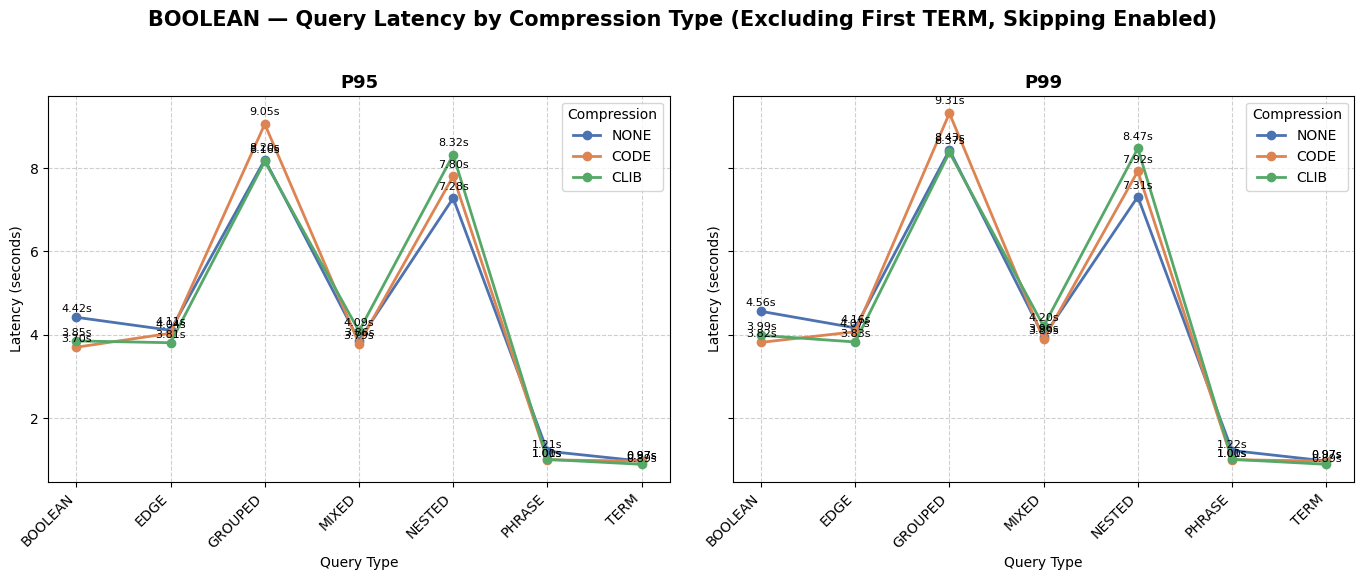

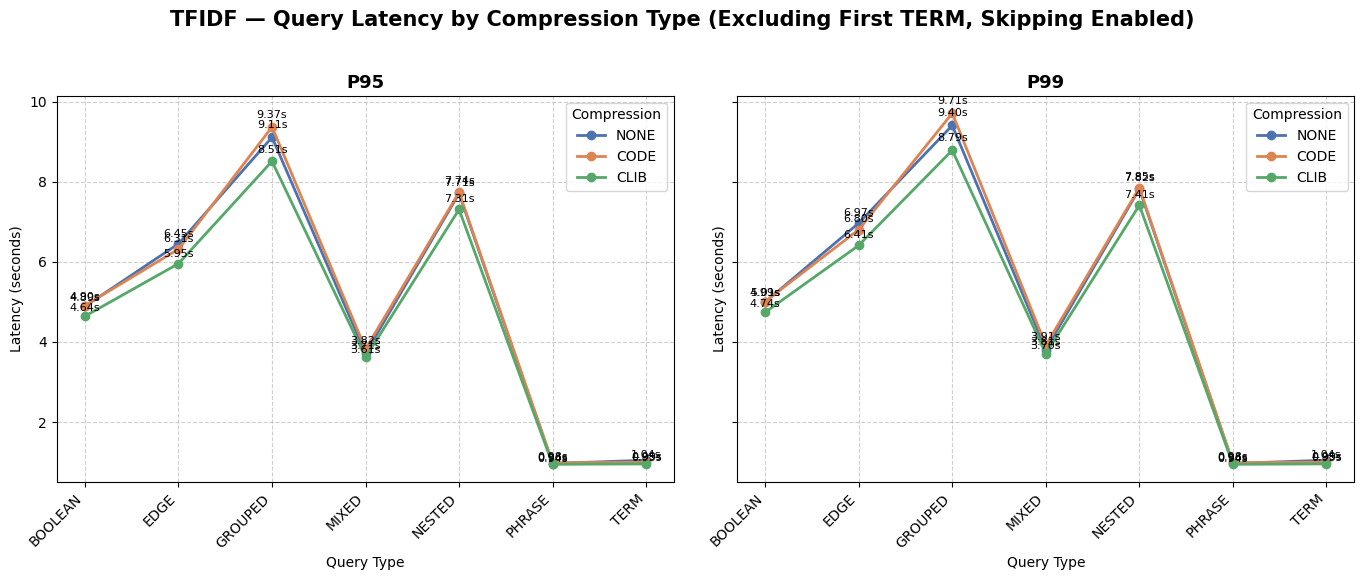

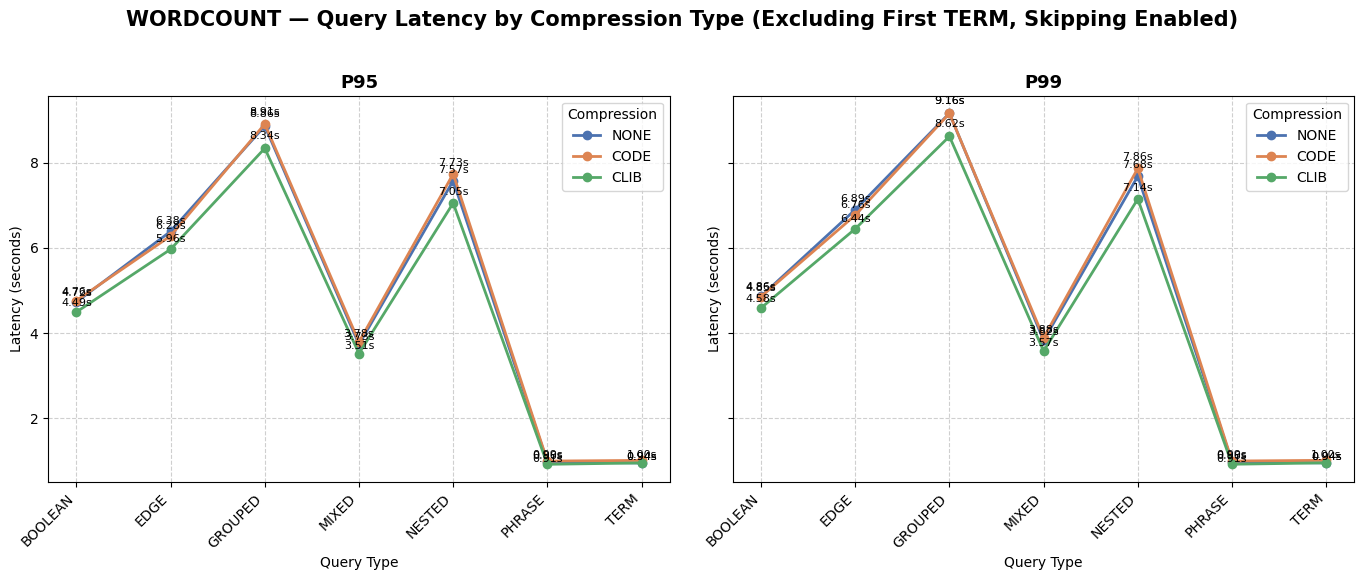

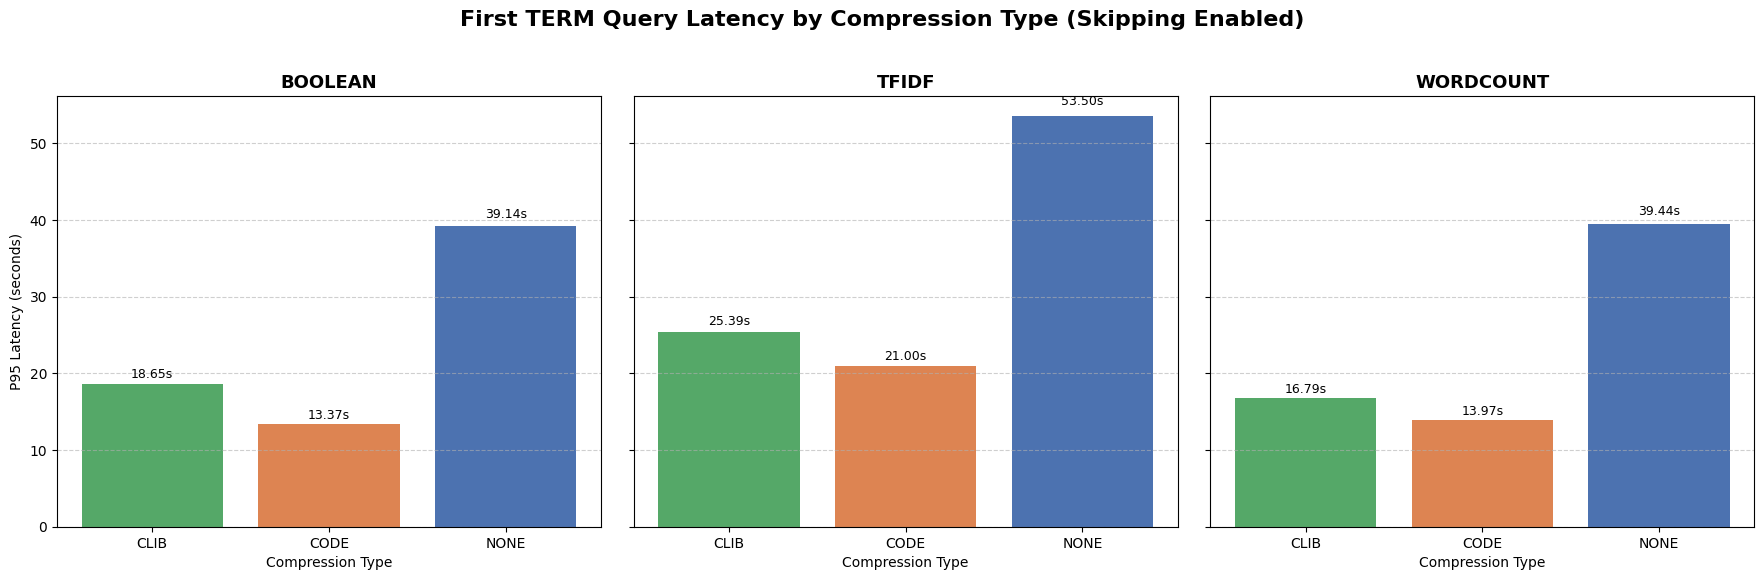

In [324]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


df = pd.read_csv("query_latency_log.csv", header=None)


df.columns = [
    "timestamp",
    "index_type",
    "info",
    "dstore",
    "compr",
    "qproc",
    "optim",
    "query",
    "query_type",
    "run_id",
    "latency_ms",
    "current_mem_kb",
    "peak_mem_kb",
]


df = df[
    (df["index_type"].str.lower() == "self")
    & (df["optim"].astype(str).str.strip().str.lower() == "skipping")
]

for col in ["info", "compr", "query_type"]:
    df[col] = df[col].astype(str).str.strip().str.upper()

df["latency_ms"] = pd.to_numeric(df["latency_ms"], errors="coerce")
df = df.dropna(subset=["latency_ms"])


df = df.sort_values("timestamp")

first_term_query = (
    df[df["query_type"] == "TERM"]
    .groupby(["info", "compr"], group_keys=False)
    .head(1)  # pick first per (info, compr)
)

df_excluding_first = df.drop(first_term_query.index)


agg = (
    df_excluding_first.groupby(["info", "compr", "query_type"])["latency_ms"]
    .agg(
        avg="mean",
        p95=lambda x: x.quantile(0.95),
        p99=lambda x: x.quantile(0.99),
    )
    .reset_index()
)

print(agg)
agg.to_csv("output.csv", index=False)


first_term_metrics = (
    first_term_query.groupby(["info", "compr"])["latency_ms"]
    .agg(
        avg="mean",
        p95=lambda x: x.quantile(0.95),
        p99=lambda x: x.quantile(0.99),
    )
    .reset_index()
)

info_types = ["BOOLEAN", "TFIDF", "WORDCOUNT"]
colors = {"NONE": "#4C72B0", "CODE": "#DD8452", "CLIB": "#55A868"}
metrics = ["p95", "p99"]

for info in info_types:
    sub_info = agg[agg["info"] == info]
    if sub_info.empty:
        continue

    fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)
    fig.suptitle(
        f"{info} — Query Latency by Compression Type (Excluding First TERM, Skipping Enabled)",
        fontsize=15,
        weight="bold",
    )

    for ax, metric in zip(axes, metrics):
        query_types = sorted(sub_info["query_type"].unique())
        x = np.arange(len(query_types))

        for compr in ["NONE", "CODE", "CLIB"]:
            sub = sub_info[sub_info["compr"] == compr].sort_values("query_type")
            if sub.empty:
                continue

            y_vals = sub[metric] / 1000.0  # Convert to seconds

            ax.plot(
                x,
                y_vals,
                label=f"{compr}",
                color=colors[compr],
                marker="o",
                linewidth=2,
                markersize=6,
            )

            # Add labels
            for i, val in enumerate(y_vals):
                ax.text(
                    x[i],
                    val + 0.02 * val,
                    f"{val:.2f}s",
                    ha="center",
                    va="bottom",
                    fontsize=8,
                )

        ax.set_xticks(x)
        ax.set_xticklabels(query_types, rotation=45, ha="right")
        ax.set_xlabel("Query Type")
        ax.set_ylabel("Latency (seconds)")
        ax.set_title(metric.upper(), fontsize=13, weight="bold")
        ax.grid(True, linestyle="--", alpha=0.6)
        ax.legend(title="Compression", frameon=True)

    plt.tight_layout(pad=2.0)
    plt.show()

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)
fig.suptitle(
    "First TERM Query Latency by Compression Type (Skipping Enabled)",
    fontsize=16,
    weight="bold",
)

for ax, info in zip(axes, info_types):
    sub = first_term_metrics[first_term_metrics["info"] == info]
    if sub.empty:
        ax.set_visible(False)
        continue

    # Convert latency to seconds
    y_vals = sub["p95"] / 1000.0

    bars = ax.bar(
        sub["compr"],
        y_vals,
        color=[colors.get(c, "#95A5A6") for c in sub["compr"]],
        edgecolor="none",
    )

    # Add labels in seconds
    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height + 0.02 * height,
            f"{height:.2f}s",
            ha="center",
            va="bottom",
            fontsize=9,
            weight="medium",
        )

    ax.set_title(info, fontsize=13, weight="bold")
    ax.set_xlabel("Compression Type")
    ax.grid(axis="y", linestyle="--", alpha=0.6)

axes[0].set_ylabel("P95 Latency (seconds)")
plt.tight_layout(pad=2.0)
plt.show()

### e). Plot.AC for q=Tn/Dn implements query processing engine with Term-at-a-time (q=Tn) and Document-at-a-time (q=Dn) with n indicating any optimizatin implemented.

In [ ]:
run_query_helper(
    "./logs/query_q1_stdout.log",
    "./logs/query_q1_stderr.log",
    "configs/config_q1.json",
)

Output saved to ./logs/query_q1_stdout.log and ./logs/query_q1_stderr.log


        info     qproc       avg       p95         p99
0    BOOLEAN   DOCATAT  5.251402  3.738366   69.592783
1    BOOLEAN  TERMATAT  3.337599  8.504336   17.065197
2      TFIDF   DOCATAT  7.200341  5.967362  102.962234
3      TFIDF  TERMATAT  3.824855  8.646262   23.895746
4  WORDCOUNT   DOCATAT  5.178247  5.476057   64.517474
5  WORDCOUNT  TERMATAT  3.823948  9.167405   16.584176


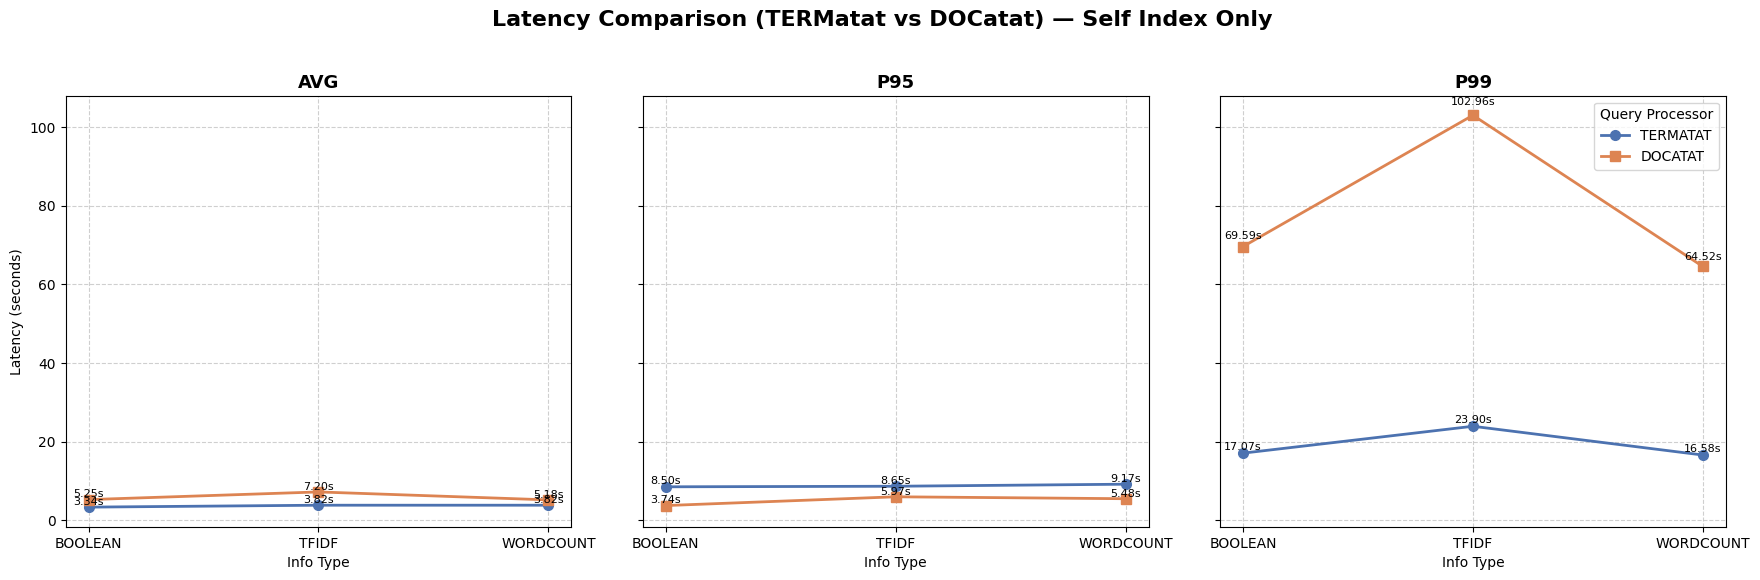

In [325]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


df = pd.read_csv("query_latency_log.csv", header=None)

df.columns = [
    "timestamp",
    "index_type",
    "info",
    "dstore",
    "compr",
    "qproc",
    "optim",
    "query",
    "query_type",
    "run_id",
    "latency_ms",
    "current_mem_kb",
    "peak_mem_kb",
]

df = df[
    (df["index_type"].str.lower() == "self")
    & (df["qproc"].isin(["TERMatat", "DOCatat"]))
]

for col in ["info", "qproc"]:
    df[col] = df[col].astype(str).str.strip().str.upper()

df["latency_ms"] = pd.to_numeric(df["latency_ms"], errors="coerce")
df = df.dropna(subset=["latency_ms"])

agg = (
    df.groupby(["info", "qproc"])["latency_ms"]
    .agg(
        avg="mean",
        p95=lambda x: x.quantile(0.95),
        p99=lambda x: x.quantile(0.99),
    )
    .reset_index()
)

for col in ["avg", "p95", "p99"]:
    agg[col] = agg[col] / 1000.0

print(agg)
metrics = ["avg", "p95", "p99"]
colors = {"TERMATAT": "#4C72B0", "DOCATAT": "#DD8452"}
markers = {"TERMATAT": "o", "DOCATAT": "s"}

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)
fig.suptitle(
    "Latency Comparison (TERMatat vs DOCatat) — Self Index Only",
    fontsize=16,
    weight="bold",
)

info_types = sorted(agg["info"].unique())

for ax, metric in zip(axes, metrics):
    for qproc in ["TERMATAT", "DOCATAT"]:
        sub = agg[agg["qproc"] == qproc].sort_values("info")

        ax.plot(
            sub["info"],
            sub[metric],
            label=qproc,
            color=colors[qproc],
            marker=markers[qproc],
            linewidth=2,
            markersize=7,
        )

        # Add value labels
        for x, y in zip(sub["info"], sub[metric]):
            ax.text(
                x,
                y + 0.02 * y,
                f"{y:.2f}s",
                ha="center",
                va="bottom",
                fontsize=8,
            )

    ax.set_title(metric.upper(), fontsize=13, weight="bold")
    ax.set_xlabel("Info Type")
    ax.grid(True, linestyle="--", alpha=0.6)

axes[0].set_ylabel("Latency (seconds)")
axes[-1].legend(title="Query Processor", frameon=True)

plt.tight_layout(pad=2.0)
plt.show()

         info     qproc query_type           avg          p95           p99
0     BOOLEAN   DOCATAT    BOOLEAN   2138.676000   3476.14575    3615.57555
1     BOOLEAN   DOCATAT       EDGE   1940.246000   3477.03860    3688.19012
2     BOOLEAN   DOCATAT    GROUPED   2236.571000   3331.97910    3341.43822
3     BOOLEAN   DOCATAT      MIXED   2531.096750   3693.25965    3724.46793
4     BOOLEAN   DOCATAT     NESTED   1353.939250   1499.47430    1528.29566
5     BOOLEAN   DOCATAT     PHRASE   1276.342000   1282.31820    1282.72604
6     BOOLEAN   DOCATAT       TERM   1243.276000   1271.19130    1273.67266
7     BOOLEAN  TERMATAT    BOOLEAN   1909.587400   4192.92400    4352.73680
8     BOOLEAN  TERMATAT       EDGE   1674.483480   4526.58840    4808.62728
9     BOOLEAN  TERMATAT    GROUPED   4577.064150   9079.71125   10506.82785
10    BOOLEAN  TERMATAT      MIXED   2049.602550   3951.61420    4582.73644
11    BOOLEAN  TERMATAT     NESTED   4313.159050   8571.29560    9331.36552
12    BOOLEA

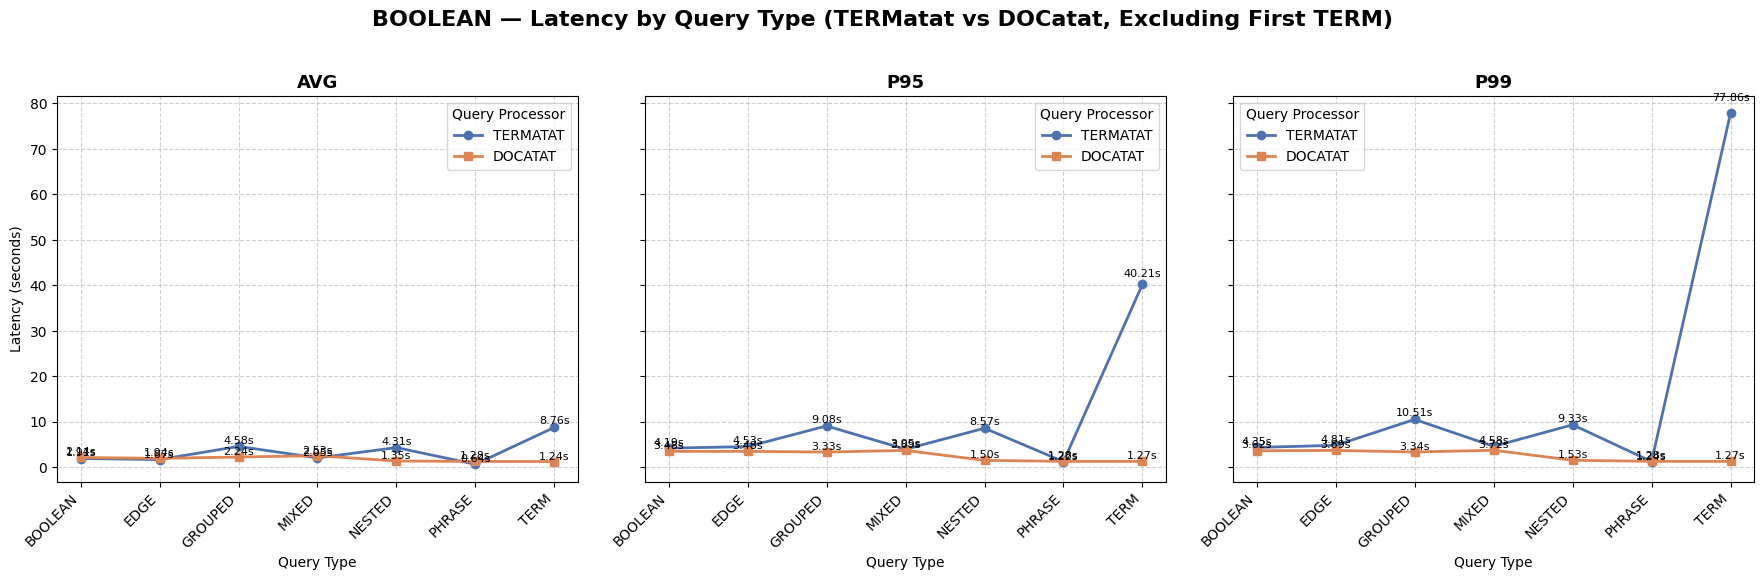

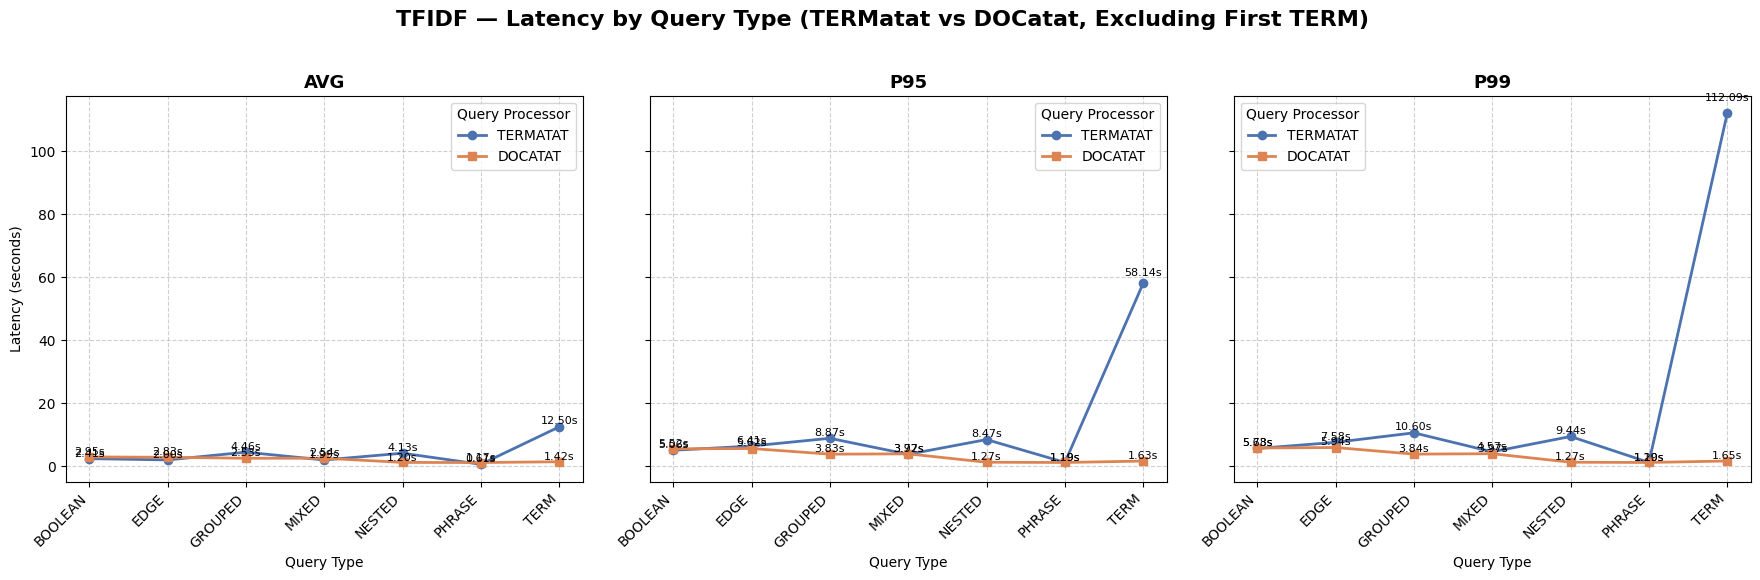

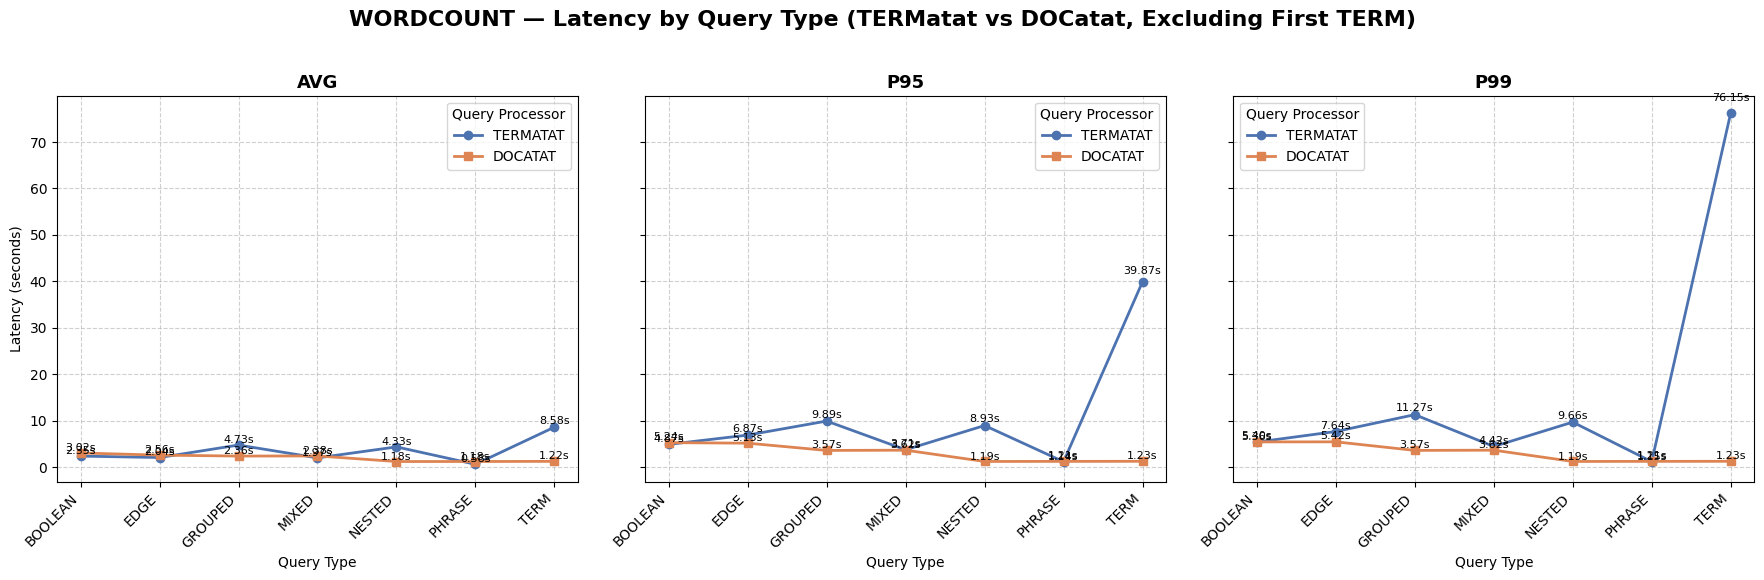

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv("query_latency_log.csv", header=None)

df.columns = [
    "timestamp",
    "index_type",
    "info",
    "dstore",
    "compr",
    "qproc",
    "optim",
    "query",
    "query_type",
    "run_id",
    "latency_ms",
    "current_mem_kb",
    "peak_mem_kb",
]

df = df[
    (df["index_type"].str.lower() == "self")
    & (df["qproc"].str.lower().isin(["termatat", "docatat"]))
    & (df["optim"].astype(str).str.strip().str.lower().isin(["null", "none", ""]))
]
for col in ["info", "qproc", "query_type"]:
    df[col] = df[col].astype(str).str.strip().str.upper()


df["latency_ms"] = pd.to_numeric(df["latency_ms"], errors="coerce")
df = df.dropna(subset=["latency_ms"])

df = df.sort_values("timestamp")

first_term_query = (
    df[df["query_type"] == "TERM"].groupby(["info", "qproc"], group_keys=False).head(1)
)
df_excluding_first = df.drop(first_term_query.index)
agg = (
    df_excluding_first.groupby(["info", "qproc", "query_type"])["latency_ms"]
    .agg(
        avg="mean",
        p95=lambda x: x.quantile(0.95),
        p99=lambda x: x.quantile(0.99),
    )
    .reset_index()
)
print(agg)
# Convert from ms → seconds
for col in ["avg", "p95", "p99"]:
    agg[col] = agg[col] / 1000.0

metrics = ["avg", "p95", "p99"]
colors = {"TERMATAT": "#4C72B0", "DOCATAT": "#DD8452"}
markers = {"TERMATAT": "o", "DOCATAT": "s"}
info_types = sorted(agg["info"].unique())
for info in info_types:
    sub_info = agg[agg["info"] == info]
    if sub_info.empty:
        continue

    fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)
    fig.suptitle(
        f"{info} — Latency by Query Type (TERMatat vs DOCatat, Excluding First TERM)",
        fontsize=16,
        weight="bold",
    )

    for ax, metric in zip(axes, metrics):
        query_types = sorted(sub_info["query_type"].unique())
        x = np.arange(len(query_types))

        for qproc in ["TERMATAT", "DOCATAT"]:
            sub = sub_info[sub_info["qproc"] == qproc].sort_values("query_type")
            if sub.empty:
                continue

            y_vals = sub[metric].values

            ax.plot(
                x,
                y_vals,
                label=qproc,
                color=colors[qproc],
                marker=markers[qproc],
                linewidth=2,
                markersize=6,
            )

            # Value labels
            for i, val in enumerate(y_vals):
                ax.text(
                    x[i],
                    val + 0.03 * val,
                    f"{val:.2f}s",
                    ha="center",
                    va="bottom",
                    fontsize=8,
                )

        ax.set_xticks(x)
        ax.set_xticklabels(query_types, rotation=45, ha="right")
        ax.set_xlabel("Query Type")
        ax.set_title(metric.upper(), fontsize=13, weight="bold")
        ax.grid(True, linestyle="--", alpha=0.6)
        ax.legend(title="Query Processor", frameon=True)

    axes[0].set_ylabel("Latency (seconds)")
    plt.tight_layout(pad=2.0)
    plt.show()

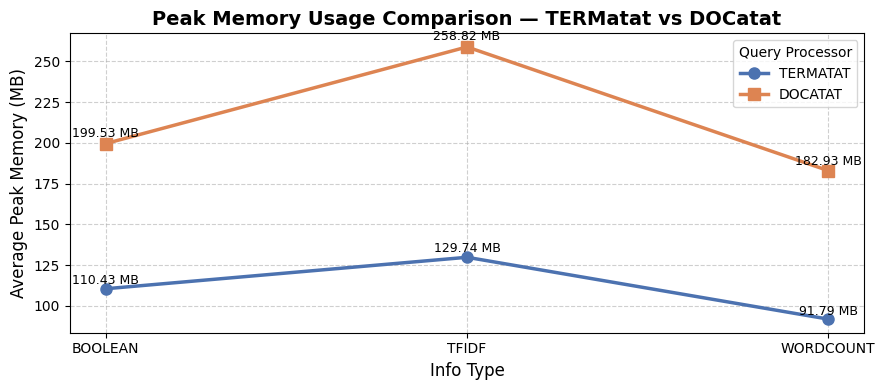

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("query_latency_log.csv", header=None)

df.columns = [
    "timestamp",
    "index_type",
    "info",
    "dstore",
    "compr",
    "qproc",
    "optim",
    "query",
    "query_type",
    "run_id",
    "latency_ms",
    "current_mem_kb",
    "peak_mem_kb",
]

df = df[
    (df["index_type"].str.lower() == "self")
    & (df["qproc"].isin(["TERMatat", "DOCatat"]))
]

for col in ["info", "qproc"]:
    df[col] = df[col].astype(str).str.strip().str.upper()

df["peak_mem_kb"] = pd.to_numeric(df["peak_mem_kb"], errors="coerce")
df = df.dropna(subset=["peak_mem_kb"])

df["peak_mem_mb"] = df["peak_mem_kb"] / 1024.0

agg = (
    df.groupby(["info", "qproc"])["peak_mem_mb"]
    .mean()
    .reset_index()
    .rename(columns={"peak_mem_mb": "avg_peak_mem_mb"})
)

plt.figure(figsize=(9, 4))
colors = {"TERMATAT": "#4C72B0", "DOCATAT": "#DD8452"}
markers = {"TERMATAT": "o", "DOCATAT": "s"}

for qproc in ["TERMATAT", "DOCATAT"]:
    sub = agg[agg["qproc"] == qproc].sort_values("info")

    plt.plot(
        sub["info"],
        sub["avg_peak_mem_mb"],
        label=qproc,
        color=colors[qproc],
        marker=markers[qproc],
        linewidth=2.5,
        markersize=8,
    )

    # Value labels
    for x, y in zip(sub["info"], sub["avg_peak_mem_mb"]):
        plt.text(
            x,
            y + 0.01 * y,
            f"{y:.2f} MB",
            ha="center",
            va="bottom",
            fontsize=9,
        )

plt.title(
    "Peak Memory Usage Comparison — TERMatat vs DOCatat", fontsize=14, weight="bold"
)
plt.xlabel("Info Type", fontsize=12)
plt.ylabel("Average Peak Memory (MB)", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(title="Query Processor")
plt.tight_layout()
plt.show()